# Swin-Unet

https://github.com/HuCaoFighting/Swin-Unet



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))

CUDA available: True
Device: cuda


## Step 1 — Segmentation DataLoader (SAHARA-compatible)

In [3]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import random

# ----------------------------------------
# UTILS
# ----------------------------------------

def normalize_image(img):
    img = img.astype(np.float32) / 255.0
    return img

def safe_copy(x):
    return np.ascontiguousarray(x)

def ensure_channel(img):
    """
    Ensure image has channel dimension.
    (H, W) -> (H, W, 1)
    """
    if img.ndim == 2:
        img = img[:, :, None]
    return img

def random_flip(img, mask, bld):
    if random.random() < 0.5:
        img = img[:, ::-1]
        mask = mask[:, ::-1]
        bld = bld[:, ::-1]

    if random.random() < 0.5:
        img = img[::-1, :]
        mask = mask[::-1, :]
        bld = bld[::-1, :]

    return img, mask, bld

def random_rotate(img, mask, bld):
    k = random.randint(0, 3)
    img = np.rot90(img, k)
    mask = np.rot90(mask, k)
    bld = np.rot90(bld, k)
    return img, mask, bld

def gaussian_noise(img):
    if random.random() < 0.3:
        img = img + np.random.normal(0, 0.02, img.shape)
    return np.clip(img, 0, 1)

def color_jitter(img):
    if random.random() < 0.5:
        img = img * (0.8 + 0.4 * random.random())
    return np.clip(img, 0, 1)

# ----------------------------------------
# CACHE
# ----------------------------------------

from collections import OrderedDict

class NPZCache:
    def __init__(self, max_size=1000):
        self.cache = OrderedDict()
        self.max_size = max_size

    def get(self, path):
        if path in self.cache:
            self.cache.move_to_end(path)
            return self.cache[path]

        data = np.load(path, mmap_mode='r')

        if len(self.cache) >= self.max_size:
            self.cache.popitem(last=False)

        self.cache[path] = data
        return data

def create_same_domain_split(
    root_dir,
    save_path,
    source_ratio=0.7,
    seed=42
):
    files = sorted([
        os.path.join(root_dir, f)
        for f in os.listdir(root_dir)
        if f.endswith(".npz")
    ])

    random.seed(seed)
    random.shuffle(files)

    n_source = int(len(files) * source_ratio)

    source_files = files[:n_source]
    target_files = files[n_source:]

    np.savez(
        save_path,
        source_files=source_files,
        target_files=target_files
    )

    print(f"✅ Saved same-domain split to: {save_path}")
    print(f"Source samples: {len(source_files)}")
    print(f"Target samples: {len(target_files)}")
# ----------------------------------------
# LABELED DATASET
# ----------------------------------------

class BuildingDamageDataset(Dataset):
    def __init__(self, root_dir, is_source=True, augment=True):
        self.files = sorted([
            os.path.join(root_dir, f)
            for f in os.listdir(root_dir)
            if f.endswith(".npz")
        ])

        random.shuffle(self.files)

        self.is_source = is_source
        self.augment = augment
        self.cache = NPZCache(max_size=1000)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = self.cache.get(self.files[idx])

        img = data["image"]           # (H,W) or (H,W,C)
        damage = data["damage_mask"]  # (H,W)
        building = data["building_mask"]  # (H,W)

        img = ensure_channel(img)
        img = normalize_image(img)

        # ----------------------------------------
        # AUGMENTATION
        # ----------------------------------------
        # ----------------------------------------
        # WEAK AUGMENTATION
        # ----------------------------------------

        weak_img = img.copy()
        weak_damage = damage.copy()
        weak_building = building.copy()

        if self.augment:

            weak_img, weak_damage, weak_building = random_flip(
                weak_img,
                weak_damage,
                weak_building
            )

            weak_img, weak_damage, weak_building = random_rotate(
                weak_img,
                weak_damage,
                weak_building
            )

        # ----------------------------------------
        # STRONG AUGMENTATION
        # ----------------------------------------

        strong_img = weak_img.copy()

        if self.augment:

            if np.any((damage == 2) | (damage == 3)):

                strong_img = gaussian_noise(strong_img)

                strong_img = color_jitter(strong_img)

            else:

                if random.random() < 0.5:
                    strong_img = gaussian_noise(strong_img)

                if random.random() < 0.3:
                    strong_img = color_jitter(strong_img)

        # ----------------------------------------
        # SAFE MEMORY
        # ----------------------------------------
        weak_img = safe_copy(weak_img)
        strong_img = safe_copy(strong_img)

        weak_damage = safe_copy(weak_damage)
        weak_building = safe_copy(weak_building)

        # ----------------------------------------
        # TO TENSOR
        # ----------------------------------------
        weak_img = np.transpose(weak_img, (2, 0, 1))
        strong_img = np.transpose(strong_img, (2, 0, 1))

        weak_img = torch.from_numpy(weak_img).float()
        strong_img = torch.from_numpy(strong_img).float()

        weak_damage = torch.from_numpy(weak_damage).long()
        weak_building = torch.from_numpy(weak_building).float()

        event_name = get_event_name(self.files[idx])

        return (
            weak_img,
            strong_img,
            weak_damage,
            weak_building,
            event_name
        )

# ----------------------------------------
# UNLABELED DATASET
# ----------------------------------------

class BuildingDamageDatasetUnlabeled(Dataset):
    """
    Unlabeled target dataset for pseudo-label training.

    Returns:
        img_w: weakly augmented image
        img_s: strongly augmented image
        building: building mask used later to restrict
                  pseudo-label loss to building regions
    """
    def __init__(self, root_dir):
        self.files = sorted([
            os.path.join(root_dir, f)
            for f in os.listdir(root_dir)
            if f.endswith(".npz")
        ])

        random.shuffle(self.files)
        self.cache = NPZCache(max_size=300)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = self.cache.get(self.files[idx])

        img = data["image"]
        building = data["building_mask"]

        img = ensure_channel(img)
        img = normalize_image(img)

        # We use building mask also during unlabeled training
        # to focus pseudo-label supervision on building regions.
        dummy_mask = building.copy()

        # Weak augmentation
        img_w = img.copy()
        bld_w = building.copy()

        img_w, _, bld_w = random_flip(img_w, dummy_mask, bld_w)

        # Strong augmentation
        # IMPORTANT: keep spatial transform identical to weak branch
        # so pseudo-label from img_w aligns with img_s
        img_s = img_w.copy()
        bld_s = bld_w.copy()

        # only appearance/noise augmentation, no separate rotation/flip
        img_s = gaussian_noise(img_s)

        if img_s.shape[-1] == 3:
            img_s = color_jitter(img_s)
        # NOTE:
        # We return one building mask. Since building mask is only
        # used as a valid supervision region, the strongly augmented
        # version is the safest choice because it aligns with img_s,
        # the branch where pseudo-label loss is applied.
        building = bld_s

        img_w = safe_copy(img_w)
        img_s = safe_copy(img_s)
        building = safe_copy(building)

        img_w = torch.from_numpy(np.transpose(img_w, (2, 0, 1))).float()
        img_s = torch.from_numpy(np.transpose(img_s, (2, 0, 1))).float()
        building = torch.from_numpy(building).float()

        return img_w, img_s, building


# ----------------------------------------
# DATALOADER
# ----------------------------------------
def get_loader(dataset, batch_size=8, shuffle=True, drop_last=True, num_workers=12,persistent_workers=True,prefetch_factor=4, pin_memory=False):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        persistent_workers=persistent_workers,
        prefetch_factor=prefetch_factor,
        pin_memory=pin_memory,
        drop_last=drop_last
    )

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import random

# ----------------------------------------
# Color map for damage classes
# 0: background
# 1: intact
# 2: major
# 3: destroyed
# ----------------------------------------
def colorize_mask(mask):
    h, w = mask.shape
    color = np.zeros((h, w, 3), dtype=np.uint8)

    color[mask == 0] = [0, 0, 0]         # background
    color[mask == 1] = [0, 255, 0]       # intact
    color[mask == 2] = [255, 165, 0]     # major
    color[mask == 3] = [255, 0, 0]       # destroyed

    return color

# ----------------------------------------
# SAR visualization
# ----------------------------------------
def visualize_sar(img):
    """
    Display SAR in a more realistic way.
    Input img shape: [H, W, C]
    """
    if img.shape[2] == 1:
        sar = img[:, :, 0]
    elif img.shape[2] == 2:
        # VV/VH style visualization
        sar = 0.6 * img[:, :, 0] + 0.4 * img[:, :, 1]
    else:
        sar = img.mean(axis=2)

    sar = np.log1p(np.maximum(sar, 0.0))
    p2, p98 = np.percentile(sar, (2, 98))
    sar = np.clip((sar - p2) / (p98 - p2 + 1e-6), 0, 1)

    return sar

# ----------------------------------------
# Main viewer
# ----------------------------------------
def show_sample(dataset, title="Sample", is_sar=False):
    idx = random.randint(0, len(dataset) - 1)

    img, damage, building = dataset[idx]

    img = img.numpy().transpose(1, 2, 0)
    damage = damage.numpy()
    building = building.numpy()

    damage_color = colorize_mask(damage)

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 3, 1)
    if is_sar:
        sar = visualize_sar(img)
        plt.imshow(sar, cmap="gray")
    else:
        plt.imshow(np.clip(img, 0, 1))
    plt.title(f"{title} - Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(damage_color)
    plt.title("Damage Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(building, cmap="gray")
    plt.title("Building Mask")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [5]:
def inspect_dataset(dataset, name="DATASET", n_samples=50):

    print(f"\n===== {name} INFO =====")
    print("Total samples:", len(dataset))

    sample = dataset[0]

    if len(sample) == 5:
        weak_img, strong_img, dmg, bld, event_name = sample

        print("Weak image shape:", weak_img.shape)
        print("Strong image shape:", strong_img.shape)
        print("Damage mask shape:", dmg.shape)
        print("Building mask shape:", bld.shape)
        print("Event name:", event_name)

    elif len(sample) == 4:
        weak_img, strong_img, dmg, bld = sample

        print("Weak image shape:", weak_img.shape)
        print("Strong image shape:", strong_img.shape)
        print("Damage mask shape:", dmg.shape)
        print("Building mask shape:", bld.shape)

    elif len(sample) == 3:
        img, dmg, bld = sample

        print("Image shape:", img.shape)
        print("Damage mask shape:", dmg.shape)
        print("Building mask shape:", bld.shape)

    else:
        raise ValueError(f"Unexpected dataset output length: {len(sample)}")

    indices = random.sample(range(len(dataset)), min(n_samples, len(dataset)))

    all_classes = set()
    event_counter = Counter()

    for idx in indices:
        sample = dataset[idx]

        if len(sample) == 5:
            _, _, dmg, _, event_name = sample
            event_counter[event_name] += 1

        elif len(sample) == 4:
            _, _, dmg, _ = sample

        else:
            _, dmg, _ = sample

        all_classes.update(np.unique(dmg.numpy()))

    print(f"\nChecked {len(indices)} samples")
    print("Observed damage classes:", sorted(all_classes))

    if len(event_counter) > 0:
        print("Observed events:")
        for ev, cnt in event_counter.most_common():
            print(f"{ev}: {cnt}")

In [ ]:
# import os
# import shutil
# import random
# from tqdm import tqdm

# # =========================================================
# # PURPOSE:
# # Create a smaller subset of NPZ dataset by randomly sampling
# # a fixed number of files. This is useful for fast debugging,
# # prototyping, or limited-resource experiments.
# # =========================================================


# def copy_subset(src_dir, dst_dir, n_files=500):
#     os.makedirs(dst_dir, exist_ok=True)

#     all_files = []
#     for root, _, filenames in os.walk(src_dir):
#         for f in filenames:
#             if f.endswith(".npz"):
#                 all_files.append(os.path.join(root, f))

#     selected = random.sample(all_files, min(n_files, len(all_files)))

#     for f in tqdm(selected, desc=f"Copying subset from {os.path.basename(src_dir)}"):
#         rel_path = os.path.relpath(f, src_dir)
#         dst_path = os.path.join(dst_dir, rel_path)

#         os.makedirs(os.path.dirname(dst_path), exist_ok=True)
#         shutil.copy2(f, dst_path)


# copy_subset("/content/drive/MyDrive/ebd_npz", "/content/ebd_npz", n_files=500)
# copy_subset("/content/drive/MyDrive/dfc25_npz", "/content/dfc25_npz", n_files=500)

In [ ]:
# import os
# import zipfile
# from tqdm import tqdm

# # =========================================================
# # PURPOSE:
# # Compress dataset directory into a ZIP file with progress
# # visualization. This helps for backup, transfer, or storage
# # optimization when working with large NPZ datasets.
# # =========================================================

# import os
# import zipfile
# from tqdm import tqdm

# def zip_with_progress(src_dir, zip_path):
#     file_paths = []

#     for root, _, files in os.walk(src_dir):
#         for file in files:
#             file_paths.append(os.path.join(root, file))

#     with zipfile.ZipFile(zip_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
#         for file in tqdm(file_paths, desc=f"Zipping {os.path.basename(src_dir)}"):
#             arcname = os.path.relpath(file, src_dir)
#             zf.write(file, arcname)

# zip_with_progress("/content/drive/MyDrive/ebd_npz",
#                   "/content/drive/MyDrive/ebd_npz.zip")

# zip_with_progress("/content/drive/MyDrive/dfc25_npz",
#                   "/content/drive/MyDrive/dfc25_npz.zip")


In [6]:
import zipfile
import shutil
from tqdm import tqdm
import os

# =========================================================
# PURPOSE:
# Extract ZIP archives of datasets with progress tracking.
# =========================================================

def unzip_with_progress(zip_path, extract_to):
    with zipfile.ZipFile(zip_path, 'r') as zf:
        members = zf.infolist()

        for member in tqdm(members, desc=f"Extracting {os.path.basename(zip_path)}"):
            zf.extract(member, extract_to)

zip_source = "/content/drive/MyDrive/ebd_npz_f.zip"
# zip_target = "/content/drive/MyDrive/dfc25_npz_f.zip"

extract_source = "/content/ebd_npz"
# extract_target = "/content/dfc25_npz"

shutil.rmtree(extract_source, ignore_errors=True)
# shutil.rmtree(extract_target, ignore_errors=True)

os.makedirs(extract_source, exist_ok=True)
# os.makedirs(extract_target, exist_ok=True)

unzip_with_progress(zip_source, extract_source)
# unzip_with_progress(zip_target, extract_target)

Extracting ebd_npz_f.zip: 100%|██████████| 31775/31775 [01:27<00:00, 362.73it/s]


In [ ]:
# SOURCE_PATH ="/content/ebd_npz" #"/content/drive/MyDrive/ebd_npz"    #4.6G
# TARGET_PATH ="/content/dfc25_npz" #"/content/drive/MyDrive/dfc25_npz"  #1.4G

# source_dataset = BuildingDamageDataset(SOURCE_PATH, is_source=True, augment=False)
# target_dataset = BuildingDamageDataset(TARGET_PATH, is_source=False, augment=False)

# inspect_dataset(source_dataset, "SOURCE", n_samples=50)
# inspect_dataset(target_dataset, "TARGET", n_samples=50)

In [7]:
import os
from collections import Counter, defaultdict

DATA_ROOT = "/content/ebd_npz"

files = sorted([
    f for f in os.listdir(DATA_ROOT)
    if f.endswith(".npz")
])

def get_event_name(filename):
    # EARTHQUAKE-TURKEY_018187_256_256.npz
    # TONGA-VOLCANO_017393_256_0.npz
    return filename.split("_")[0]

event_counts = Counter(get_event_name(f) for f in files)

print("Number of files:", len(files))
print("Number of unique events:", len(event_counts))

print("\n===== Events =====")
for event, count in event_counts.most_common():
    print(f"{event}: {count}")

Number of files: 31775
Number of unique events: 10

===== Events =====
HURRICANE-IAN: 13465
HURRICANE-IDA: 7263
HURRICANE-DELTA: 2641
EARTHQUAKE-TURKEY: 2589
HURRICANE-IRMA: 1302
STVINCENT-VOLCANO: 1013
HURRICANE-LAURA: 991
TONGA-VOLCANO: 956
MOUNT-SEMERU-ERUPTION: 943
TEXAS-TORNADOES: 612


In [8]:
import os
import numpy as np
from collections import Counter

split_dir = "/content/drive/MyDrive/STRATA_runs/splits"
os.makedirs(split_dir, exist_ok=True)

event_split_path = os.path.join(
    split_dir,
    "ebd_optical_event_split_EQTURKEY_TEXASTORNADO_HURDELTA_HURIDA_target.npz"
)

TARGET_EVENTS = {
    "EARTHQUAKE-TURKEY",
    "TEXAS-TORNADOES",
    "HURRICANE-DELTA",
    "HURRICANE-IDA",
}

DATA_ROOT = "/content/ebd_npz"


def get_event_name_from_path(path):
    fname = os.path.basename(path)
    return fname.split("_")[0]

def create_event_based_split(root_dir, save_path, target_events):
    all_files = sorted([
        os.path.join(root_dir, f)
        for f in os.listdir(root_dir)
        if f.endswith(".npz")
    ])

    source_files = []
    target_files = []

    for f in all_files:
        event_name = get_event_name_from_path(f)

        if event_name in target_events:
            target_files.append(f)
        else:
            source_files.append(f)

    np.savez(
        save_path,
        source_files=source_files,
        target_files=target_files,
        target_events=list(target_events)
    )

    print(f"✅ Saved event-based split to: {save_path}")
    print(f"Source samples: {len(source_files)}")
    print(f"Target samples: {len(target_files)}")

    print("\nSource event counts:")
    for event, count in Counter(get_event_name_from_path(f) for f in source_files).most_common():
        print(f"{event}: {count}")

    print("\nTarget event counts:")
    for event, count in Counter(get_event_name_from_path(f) for f in target_files).most_common():
        print(f"{event}: {count}")

if not os.path.exists(event_split_path):
    create_event_based_split(
        root_dir=DATA_ROOT,
        save_path=event_split_path,
        target_events=TARGET_EVENTS
    )

split_data = np.load(event_split_path, allow_pickle=True)

source_files = list(split_data["source_files"])
target_files = list(split_data["target_files"])

SOURCE_PATH = DATA_ROOT

source_dataset = BuildingDamageDataset(
    SOURCE_PATH,
    is_source=True,
    augment=False
)

target_dataset = BuildingDamageDataset(
    SOURCE_PATH,
    is_source=False,
    augment=False
)

source_dataset.files = source_files
target_dataset.files = target_files

inspect_dataset(source_dataset, "SOURCE_EVENT_BASED", n_samples=50)
inspect_dataset(target_dataset, "TARGET_EVENT_BASED", n_samples=50)


===== SOURCE_EVENT_BASED INFO =====
Total samples: 18670
Weak image shape: torch.Size([3, 256, 256])
Strong image shape: torch.Size([3, 256, 256])
Damage mask shape: torch.Size([256, 256])
Building mask shape: torch.Size([256, 256])
Event name: /content/ebd

Checked 50 samples
Observed damage classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Observed events:
/content/ebd: 50

===== TARGET_EVENT_BASED INFO =====
Total samples: 13105
Weak image shape: torch.Size([3, 256, 256])
Strong image shape: torch.Size([3, 256, 256])
Damage mask shape: torch.Size([256, 256])
Building mask shape: torch.Size([256, 256])
Event name: /content/ebd

Checked 50 samples
Observed damage classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Observed events:
/content/ebd: 50


In [ ]:
from collections import defaultdict
import numpy as np

class_file_counts = defaultdict(int)

for f in target_files:
    with np.load(f) as data:
        mask = data["damage_mask"]
    classes = np.unique(mask)

    for c in classes:
        if c != 0:
            class_file_counts[int(c)] += 1

print("Target class file availability:")
for c in sorted(class_file_counts):
    print(c, class_file_counts[c])

Target class file availability:
1 12698
2 1228
3 897


SOURCE (Optical)


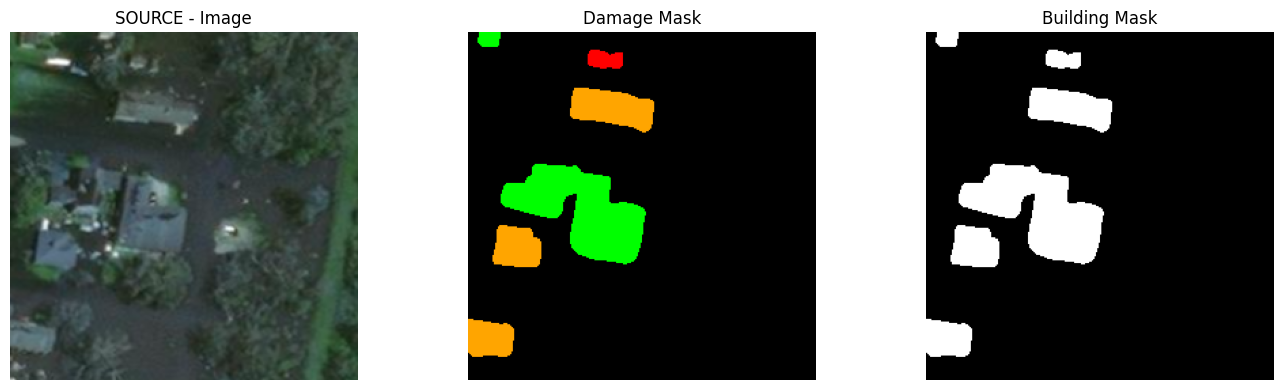

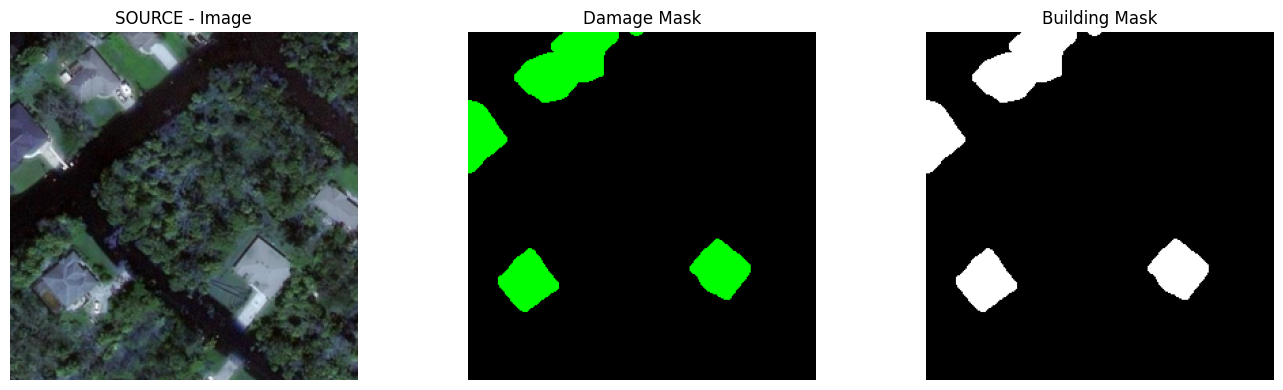

TARGET (SAR)


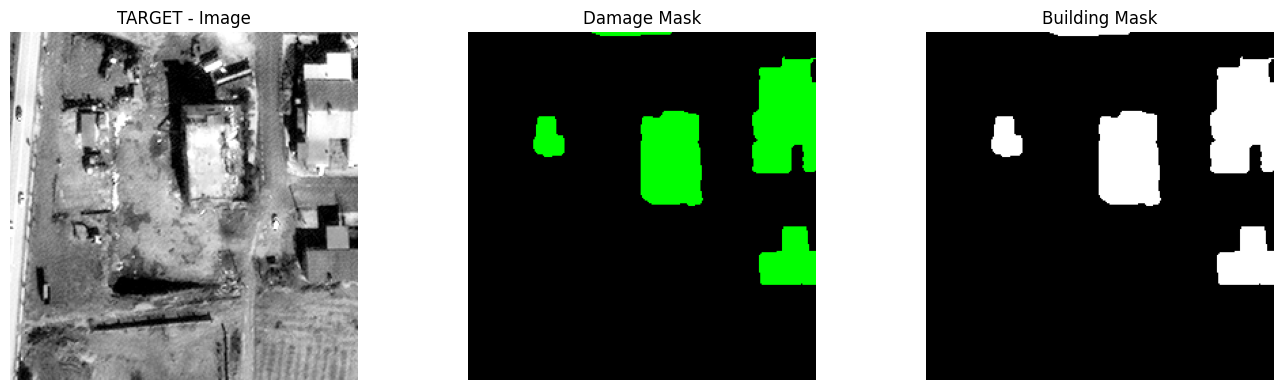

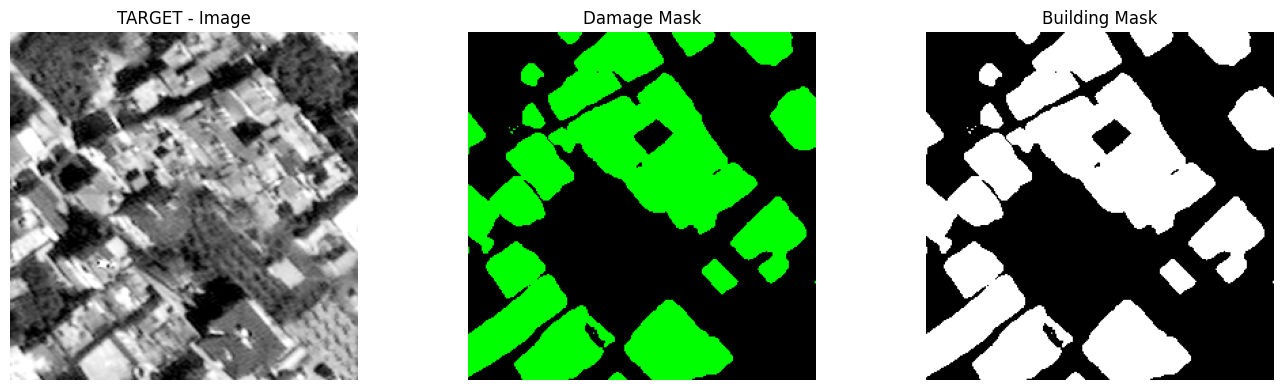

In [ ]:
print("SOURCE (Optical)")
for _ in range(2):
    show_sample(source_dataset, title="SOURCE", is_sar=False)

print("TARGET (SAR)")
for _ in range(2):
    show_sample(target_dataset, title="TARGET", is_sar=True)

## Step 2.1 — Rewrite backbone_resnet.py for segmentation SAHARA

In [9]:
# ! pip install transformers==4.37.2

In [10]:
import torch
import torch.nn as nn
import torch.utils.checkpoint as checkpoint
import torch.nn.functional as F

from einops import rearrange
from timm.models.layers import DropPath, to_2tuple, trunc_normal_


# ============================================
# MLP
# ============================================

class Mlp(nn.Module):

    def __init__(
        self,
        in_features,
        hidden_features=None,
        out_features=None,
        act_layer=nn.GELU,
        drop=0.0
    ):
        super().__init__()

        out_features = out_features or in_features
        hidden_features = hidden_features or in_features

        self.fc1 = nn.Linear(
            in_features,
            hidden_features
        )

        self.act = act_layer()

        self.fc2 = nn.Linear(
            hidden_features,
            out_features
        )

        self.drop = nn.Dropout(drop)

    def forward(self, x):

        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)

        x = self.fc2(x)
        x = self.drop(x)

        return x


# ============================================
# WINDOW PARTITION / REVERSE
# ============================================

def window_partition(x, window_size):

    B, H, W, C = x.shape

    x = x.view(
        B,
        H // window_size,
        window_size,
        W // window_size,
        window_size,
        C
    )

    windows = (
        x.permute(0, 1, 3, 2, 4, 5)
        .contiguous()
        .view(-1, window_size, window_size, C)
    )

    return windows


def window_reverse(windows, window_size, H, W):

    B = int(
        windows.shape[0]
        / (H * W / window_size / window_size)
    )

    x = windows.view(
        B,
        H // window_size,
        W // window_size,
        window_size,
        window_size,
        -1
    )

    x = (
        x.permute(0, 1, 3, 2, 4, 5)
        .contiguous()
        .view(B, H, W, -1)
    )

    return x


# ============================================
# WINDOW ATTENTION
# ============================================

class WindowAttention(nn.Module):

    def __init__(
        self,
        dim,
        window_size,
        num_heads,
        qkv_bias=True,
        qk_scale=None,
        attn_drop=0.0,
        proj_drop=0.0
    ):
        super().__init__()

        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads

        head_dim = dim // num_heads

        self.scale = qk_scale or head_dim ** -0.5

        self.relative_position_bias_table = nn.Parameter(
            torch.zeros(
                (2 * window_size[0] - 1)
                * (2 * window_size[1] - 1),
                num_heads
            )
        )

        coords_h = torch.arange(
            self.window_size[0]
        )

        coords_w = torch.arange(
            self.window_size[1]
        )

        coords = torch.stack(
            torch.meshgrid(
                [
                    coords_h,
                    coords_w
                ],
                indexing="ij"
            )
        )

        coords_flatten = torch.flatten(
            coords,
            1
        )

        relative_coords = (
            coords_flatten[:, :, None]
            - coords_flatten[:, None, :]
        )

        relative_coords = (
            relative_coords
            .permute(1, 2, 0)
            .contiguous()
        )

        relative_coords[:, :, 0] += (
            self.window_size[0] - 1
        )

        relative_coords[:, :, 1] += (
            self.window_size[1] - 1
        )

        relative_coords[:, :, 0] *= (
            2 * self.window_size[1] - 1
        )

        relative_position_index = (
            relative_coords.sum(-1)
        )

        self.register_buffer(
            "relative_position_index",
            relative_position_index
        )

        self.qkv = nn.Linear(
            dim,
            dim * 3,
            bias=qkv_bias
        )

        self.attn_drop = nn.Dropout(
            attn_drop
        )

        self.proj = nn.Linear(
            dim,
            dim
        )

        self.proj_drop = nn.Dropout(
            proj_drop
        )

        trunc_normal_(
            self.relative_position_bias_table,
            std=0.02
        )

        self.softmax = nn.Softmax(dim=-1)

    def forward(
        self,
        x,
        mask=None
    ):

        B_, N, C = x.shape

        qkv = (
            self.qkv(x)
            .reshape(
                B_,
                N,
                3,
                self.num_heads,
                C // self.num_heads
            )
            .permute(2, 0, 3, 1, 4)
        )

        q, k, v = qkv[0], qkv[1], qkv[2]

        q = q * self.scale

        attn = (
            q @ k.transpose(-2, -1)
        )

        relative_position_bias = (
            self.relative_position_bias_table[
                self.relative_position_index.view(-1)
            ]
            .view(
                self.window_size[0] * self.window_size[1],
                self.window_size[0] * self.window_size[1],
                -1
            )
        )

        relative_position_bias = (
            relative_position_bias
            .permute(2, 0, 1)
            .contiguous()
        )

        attn = attn + relative_position_bias.unsqueeze(0)

        if mask is not None:

            nW = mask.shape[0]

            attn = (
                attn.view(
                    B_ // nW,
                    nW,
                    self.num_heads,
                    N,
                    N
                )
                + mask.unsqueeze(1).unsqueeze(0)
            )

            attn = attn.view(
                -1,
                self.num_heads,
                N,
                N
            )

            attn = self.softmax(attn)

        else:

            attn = self.softmax(attn)

        attn = self.attn_drop(attn)

        x = (
            attn @ v
        ).transpose(1, 2).reshape(B_, N, C)

        x = self.proj(x)
        x = self.proj_drop(x)

        return x


# ============================================
# SWIN TRANSFORMER BLOCK
# ============================================

class SwinTransformerBlock(nn.Module):

    def __init__(
        self,
        dim,
        input_resolution,
        num_heads,
        window_size=7,
        shift_size=0,
        mlp_ratio=4.0,
        qkv_bias=True,
        qk_scale=None,
        drop=0.0,
        attn_drop=0.0,
        drop_path=0.0,
        act_layer=nn.GELU,
        norm_layer=nn.LayerNorm
    ):
        super().__init__()

        self.dim = dim
        self.input_resolution = input_resolution
        self.num_heads = num_heads
        self.window_size = window_size
        self.shift_size = shift_size
        self.mlp_ratio = mlp_ratio

        if min(self.input_resolution) <= self.window_size:

            self.shift_size = 0
            self.window_size = min(self.input_resolution)

        assert 0 <= self.shift_size < self.window_size

        self.norm1 = norm_layer(dim)

        self.attn = WindowAttention(
            dim,
            window_size=to_2tuple(self.window_size),
            num_heads=num_heads,
            qkv_bias=qkv_bias,
            qk_scale=qk_scale,
            attn_drop=attn_drop,
            proj_drop=drop
        )

        self.drop_path = (
            DropPath(drop_path)
            if drop_path > 0.0
            else nn.Identity()
        )

        self.norm2 = norm_layer(dim)

        mlp_hidden_dim = int(
            dim * mlp_ratio
        )

        self.mlp = Mlp(
            in_features=dim,
            hidden_features=mlp_hidden_dim,
            act_layer=act_layer,
            drop=drop
        )

        if self.shift_size > 0:

            H, W = self.input_resolution

            img_mask = torch.zeros(
                (1, H, W, 1)
            )

            h_slices = (
                slice(0, -self.window_size),
                slice(-self.window_size, -self.shift_size),
                slice(-self.shift_size, None)
            )

            w_slices = (
                slice(0, -self.window_size),
                slice(-self.window_size, -self.shift_size),
                slice(-self.shift_size, None)
            )

            cnt = 0

            for h in h_slices:
                for w in w_slices:

                    img_mask[:, h, w, :] = cnt
                    cnt += 1

            mask_windows = window_partition(
                img_mask,
                self.window_size
            )

            mask_windows = mask_windows.view(
                -1,
                self.window_size * self.window_size
            )

            attn_mask = (
                mask_windows.unsqueeze(1)
                - mask_windows.unsqueeze(2)
            )

            attn_mask = (
                attn_mask
                .masked_fill(
                    attn_mask != 0,
                    float(-100.0)
                )
                .masked_fill(
                    attn_mask == 0,
                    float(0.0)
                )
            )

        else:

            attn_mask = None

        self.register_buffer(
            "attn_mask",
            attn_mask
        )

    def forward(self, x):

        H, W = self.input_resolution
        B, L, C = x.shape

        assert L == H * W, "input feature has wrong size"

        shortcut = x

        x = self.norm1(x)
        x = x.view(B, H, W, C)

        if self.shift_size > 0:

            shifted_x = torch.roll(
                x,
                shifts=(-self.shift_size, -self.shift_size),
                dims=(1, 2)
            )

        else:

            shifted_x = x

        x_windows = window_partition(
            shifted_x,
            self.window_size
        )

        x_windows = x_windows.view(
            -1,
            self.window_size * self.window_size,
            C
        )

        attn_windows = self.attn(
            x_windows,
            mask=self.attn_mask
        )

        attn_windows = attn_windows.view(
            -1,
            self.window_size,
            self.window_size,
            C
        )

        shifted_x = window_reverse(
            attn_windows,
            self.window_size,
            H,
            W
        )

        if self.shift_size > 0:

            x = torch.roll(
                shifted_x,
                shifts=(self.shift_size, self.shift_size),
                dims=(1, 2)
            )

        else:

            x = shifted_x

        x = x.view(B, H * W, C)

        x = shortcut + self.drop_path(x)

        x = x + self.drop_path(
            self.mlp(
                self.norm2(x)
            )
        )

        return x


# ============================================
# PATCH MERGING
# ============================================

class PatchMerging(nn.Module):

    def __init__(
        self,
        input_resolution,
        dim,
        norm_layer=nn.LayerNorm
    ):
        super().__init__()

        self.input_resolution = input_resolution
        self.dim = dim

        self.reduction = nn.Linear(
            4 * dim,
            2 * dim,
            bias=False
        )

        self.norm = norm_layer(
            4 * dim
        )

    def forward(self, x):

        H, W = self.input_resolution
        B, L, C = x.shape

        assert L == H * W
        assert H % 2 == 0 and W % 2 == 0

        x = x.view(B, H, W, C)

        x0 = x[:, 0::2, 0::2, :]
        x1 = x[:, 1::2, 0::2, :]
        x2 = x[:, 0::2, 1::2, :]
        x3 = x[:, 1::2, 1::2, :]

        x = torch.cat(
            [x0, x1, x2, x3],
            dim=-1
        )

        x = x.view(
            B,
            -1,
            4 * C
        )

        x = self.norm(x)
        x = self.reduction(x)

        return x


# ============================================
# PATCH EXPAND
# ============================================

class PatchExpand(nn.Module):

    def __init__(
        self,
        input_resolution,
        dim,
        dim_scale=2,
        norm_layer=nn.LayerNorm
    ):
        super().__init__()

        self.input_resolution = input_resolution
        self.dim = dim

        self.expand = (
            nn.Linear(
                dim,
                2 * dim,
                bias=False
            )
            if dim_scale == 2
            else nn.Identity()
        )

        self.norm = norm_layer(
            dim // dim_scale
        )

    def forward(self, x):

        H, W = self.input_resolution

        x = self.expand(x)

        B, L, C = x.shape

        assert L == H * W

        x = x.view(B, H, W, C)

        x = rearrange(
            x,
            "b h w (p1 p2 c)-> b (h p1) (w p2) c",
            p1=2,
            p2=2,
            c=C // 4
        )

        x = x.view(
            B,
            -1,
            C // 4
        )

        x = self.norm(x)

        return x


class FinalPatchExpand_X4(nn.Module):

    def __init__(
        self,
        input_resolution,
        dim,
        dim_scale=4,
        norm_layer=nn.LayerNorm
    ):
        super().__init__()

        self.input_resolution = input_resolution
        self.dim = dim
        self.dim_scale = dim_scale

        self.expand = nn.Linear(
            dim,
            16 * dim,
            bias=False
        )

        self.output_dim = dim

        self.norm = norm_layer(
            self.output_dim
        )

    def forward(self, x):

        H, W = self.input_resolution

        x = self.expand(x)

        B, L, C = x.shape

        assert L == H * W

        x = x.view(B, H, W, C)

        x = rearrange(
            x,
            "b h w (p1 p2 c)-> b (h p1) (w p2) c",
            p1=self.dim_scale,
            p2=self.dim_scale,
            c=C // (self.dim_scale ** 2)
        )

        x = x.view(
            B,
            -1,
            self.output_dim
        )

        x = self.norm(x)

        return x


# ============================================
# BASIC LAYER ENCODER
# ============================================

class BasicLayer(nn.Module):

    def __init__(
        self,
        dim,
        input_resolution,
        depth,
        num_heads,
        window_size,
        mlp_ratio=4.0,
        qkv_bias=True,
        qk_scale=None,
        drop=0.0,
        attn_drop=0.0,
        drop_path=0.0,
        norm_layer=nn.LayerNorm,
        downsample=None,
        use_checkpoint=False
    ):
        super().__init__()

        self.dim = dim
        self.input_resolution = input_resolution
        self.depth = depth
        self.use_checkpoint = use_checkpoint

        self.blocks = nn.ModuleList([
            SwinTransformerBlock(
                dim=dim,
                input_resolution=input_resolution,
                num_heads=num_heads,
                window_size=window_size,
                shift_size=0 if (i % 2 == 0) else window_size // 2,
                mlp_ratio=mlp_ratio,
                qkv_bias=qkv_bias,
                qk_scale=qk_scale,
                drop=drop,
                attn_drop=attn_drop,
                drop_path=drop_path[i] if isinstance(drop_path, list) else drop_path,
                norm_layer=norm_layer
            )
            for i in range(depth)
        ])

        if downsample is not None:

            self.downsample = downsample(
                input_resolution,
                dim=dim,
                norm_layer=norm_layer
            )

        else:

            self.downsample = None

    def forward(self, x):

        for blk in self.blocks:

            if self.use_checkpoint:

                x = checkpoint.checkpoint(
                    blk,
                    x,
                    use_reentrant=False
                )

            else:

                x = blk(x)

        if self.downsample is not None:

            x = self.downsample(x)

        return x


# ============================================
# BASIC LAYER DECODER
# ============================================

class BasicLayer_up(nn.Module):

    def __init__(
        self,
        dim,
        input_resolution,
        depth,
        num_heads,
        window_size,
        mlp_ratio=4.0,
        qkv_bias=True,
        qk_scale=None,
        drop=0.0,
        attn_drop=0.0,
        drop_path=0.0,
        norm_layer=nn.LayerNorm,
        upsample=None,
        use_checkpoint=False
    ):
        super().__init__()

        self.dim = dim
        self.input_resolution = input_resolution
        self.depth = depth
        self.use_checkpoint = use_checkpoint

        self.blocks = nn.ModuleList([
            SwinTransformerBlock(
                dim=dim,
                input_resolution=input_resolution,
                num_heads=num_heads,
                window_size=window_size,
                shift_size=0 if (i % 2 == 0) else window_size // 2,
                mlp_ratio=mlp_ratio,
                qkv_bias=qkv_bias,
                qk_scale=qk_scale,
                drop=drop,
                attn_drop=attn_drop,
                drop_path=drop_path[i] if isinstance(drop_path, list) else drop_path,
                norm_layer=norm_layer
            )
            for i in range(depth)
        ])

        if upsample is not None:

            self.upsample = PatchExpand(
                input_resolution,
                dim=dim,
                dim_scale=2,
                norm_layer=norm_layer
            )

        else:

            self.upsample = None

    def forward(self, x):

        for blk in self.blocks:

            if self.use_checkpoint:

                x = checkpoint.checkpoint(
                    blk,
                    x,
                    use_reentrant=False
                )

            else:

                x = blk(x)

        if self.upsample is not None:

            x = self.upsample(x)

        return x


# ============================================
# PATCH EMBED
# ============================================

class PatchEmbed(nn.Module):

    def __init__(
        self,
        img_size=256,
        patch_size=4,
        in_chans=3,
        embed_dim=96,
        norm_layer=None
    ):
        super().__init__()

        img_size = to_2tuple(img_size)
        patch_size = to_2tuple(patch_size)

        patches_resolution = [
            img_size[0] // patch_size[0],
            img_size[1] // patch_size[1]
        ]

        self.img_size = img_size
        self.patch_size = patch_size
        self.patches_resolution = patches_resolution
        self.num_patches = (
            patches_resolution[0]
            * patches_resolution[1]
        )

        self.in_chans = in_chans
        self.embed_dim = embed_dim

        self.proj = nn.Conv2d(
            in_chans,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

        if norm_layer is not None:

            self.norm = norm_layer(
                embed_dim
            )

        else:

            self.norm = None

    def forward(self, x):

        B, C, H, W = x.shape

        assert H == self.img_size[0] and W == self.img_size[1], (
            f"Input image size ({H}*{W}) does not match model "
            f"({self.img_size[0]}*{self.img_size[1]})."
        )

        x = (
            self.proj(x)
            .flatten(2)
            .transpose(1, 2)
        )

        if self.norm is not None:

            x = self.norm(x)

        return x


# ============================================
# SWIN-UNET SYSTEM
# Official Swin-Unet style
# ============================================

class SwinTransformerSys(nn.Module):

    def __init__(
        self,
        img_size=256,
        patch_size=4,
        in_chans=3,
        num_classes=4,
        embed_dim=96,
        depths=[2, 2, 2, 2],
        depths_decoder=[1, 2, 2, 2],
        num_heads=[3, 6, 12, 24],
        window_size=8,
        mlp_ratio=4.0,
        qkv_bias=True,
        qk_scale=None,
        drop_rate=0.0,
        attn_drop_rate=0.0,
        drop_path_rate=0.1,
        norm_layer=nn.LayerNorm,
        ape=False,
        patch_norm=True,
        use_checkpoint=False,
        final_upsample="expand_first"
    ):
        super().__init__()

        self.num_classes = num_classes
        self.num_layers = len(depths)
        self.embed_dim = embed_dim
        self.ape = ape
        self.patch_norm = patch_norm
        self.num_features = int(
            embed_dim * 2 ** (self.num_layers - 1)
        )

        self.num_features_up = int(
            embed_dim * 2
        )

        self.mlp_ratio = mlp_ratio
        self.final_upsample = final_upsample

        self.patch_embed = PatchEmbed(
            img_size=img_size,
            patch_size=patch_size,
            in_chans=in_chans,
            embed_dim=embed_dim,
            norm_layer=norm_layer if self.patch_norm else None
        )

        num_patches = self.patch_embed.num_patches
        patches_resolution = self.patch_embed.patches_resolution

        self.patches_resolution = patches_resolution

        if self.ape:

            self.absolute_pos_embed = nn.Parameter(
                torch.zeros(
                    1,
                    num_patches,
                    embed_dim
                )
            )

            trunc_normal_(
                self.absolute_pos_embed,
                std=0.02
            )

        self.pos_drop = nn.Dropout(
            p=drop_rate
        )

        dpr = [
            x.item()
            for x in torch.linspace(
                0,
                drop_path_rate,
                sum(depths)
            )
        ]

        # Encoder
        self.layers = nn.ModuleList()

        for i_layer in range(self.num_layers):

            layer = BasicLayer(
                dim=int(embed_dim * 2 ** i_layer),
                input_resolution=(
                    patches_resolution[0] // (2 ** i_layer),
                    patches_resolution[1] // (2 ** i_layer)
                ),
                depth=depths[i_layer],
                num_heads=num_heads[i_layer],
                window_size=window_size,
                mlp_ratio=self.mlp_ratio,
                qkv_bias=qkv_bias,
                qk_scale=qk_scale,
                drop=drop_rate,
                attn_drop=attn_drop_rate,
                drop_path=dpr[
                    sum(depths[:i_layer]):
                    sum(depths[:i_layer + 1])
                ],
                norm_layer=norm_layer,
                downsample=PatchMerging
                if (i_layer < self.num_layers - 1)
                else None,
                use_checkpoint=use_checkpoint
            )

            self.layers.append(layer)

        # Decoder
        self.layers_up = nn.ModuleList()
        self.concat_back_dim = nn.ModuleList()

        for i_layer in range(self.num_layers):

            concat_linear = (
                nn.Linear(
                    2 * int(
                        embed_dim
                        * 2 ** (self.num_layers - 1 - i_layer)
                    ),
                    int(
                        embed_dim
                        * 2 ** (self.num_layers - 1 - i_layer)
                    )
                )
                if i_layer > 0
                else nn.Identity()
            )

            if i_layer == 0:

                layer_up = PatchExpand(
                    input_resolution=(
                        patches_resolution[0]
                        // (2 ** (self.num_layers - 1 - i_layer)),
                        patches_resolution[1]
                        // (2 ** (self.num_layers - 1 - i_layer))
                    ),
                    dim=int(
                        embed_dim
                        * 2 ** (self.num_layers - 1 - i_layer)
                    ),
                    dim_scale=2,
                    norm_layer=norm_layer
                )

            else:

                layer_up = BasicLayer_up(
                    dim=int(
                        embed_dim
                        * 2 ** (self.num_layers - 1 - i_layer)
                    ),
                    input_resolution=(
                        patches_resolution[0]
                        // (2 ** (self.num_layers - 1 - i_layer)),
                        patches_resolution[1]
                        // (2 ** (self.num_layers - 1 - i_layer))
                    ),
                    depth=depths[
                        self.num_layers - 1 - i_layer
                    ],
                    num_heads=num_heads[
                        self.num_layers - 1 - i_layer
                    ],
                    window_size=window_size,
                    mlp_ratio=self.mlp_ratio,
                    qkv_bias=qkv_bias,
                    qk_scale=qk_scale,
                    drop=drop_rate,
                    attn_drop=attn_drop_rate,
                    drop_path=dpr[
                        sum(depths[:self.num_layers - 1 - i_layer]):
                        sum(depths[:self.num_layers - i_layer])
                    ],
                    norm_layer=norm_layer,
                    upsample=PatchExpand
                    if (i_layer < self.num_layers - 1)
                    else None,
                    use_checkpoint=use_checkpoint
                )

            self.layers_up.append(layer_up)
            self.concat_back_dim.append(concat_linear)

        self.norm = norm_layer(
            self.num_features
        )

        self.norm_up = norm_layer(
            self.embed_dim
        )

        if self.final_upsample == "expand_first":

            self.up = FinalPatchExpand_X4(
                input_resolution=(
                    img_size // patch_size,
                    img_size // patch_size
                ),
                dim_scale=4,
                dim=embed_dim
            )

            self.output = nn.Conv2d(
                in_channels=embed_dim,
                out_channels=self.num_classes,
                kernel_size=1,
                bias=False
            )

        self.apply(self._init_weights)

    def _init_weights(self, m):

        if isinstance(m, nn.Linear):

            trunc_normal_(
                m.weight,
                std=0.02
            )

            if m.bias is not None:

                nn.init.constant_(
                    m.bias,
                    0
                )

        elif isinstance(m, nn.LayerNorm):

            nn.init.constant_(
                m.bias,
                0
            )

            nn.init.constant_(
                m.weight,
                1.0
            )

    def forward_features(self, x):

        x = self.patch_embed(x)

        if self.ape:

            x = x + self.absolute_pos_embed

        x = self.pos_drop(x)

        x_downsample = []

        for layer in self.layers:

            x_downsample.append(x)
            x = layer(x)

        x = self.norm(x)

        return x, x_downsample

    def forward_up_features(
        self,
        x,
        x_downsample
    ):

        for inx, layer_up in enumerate(self.layers_up):

            if inx == 0:

                x = layer_up(x)

            else:

                x = torch.cat(
                    [
                        x,
                        x_downsample[3 - inx]
                    ],
                    dim=-1
                )

                x = self.concat_back_dim[inx](x)

                x = layer_up(x)

        x = self.norm_up(x)

        return x

    def up_x4(self, x):

        H, W = self.patches_resolution
        B, L, C = x.shape

        assert L == H * W

        if self.final_upsample == "expand_first":

            x = self.up(x)

            x = x.view(
                B,
                4 * H,
                4 * W,
                -1
            )

            x = x.permute(
                0,
                3,
                1,
                2
            )

            x = self.output(x)

        return x

    def forward(self, x):

        x, x_downsample = self.forward_features(x)

        feat = x

        x = self.forward_up_features(
            x,
            x_downsample
        )

        x = self.up_x4(x)

        return x, feat


# ============================================
# SWIN-UNET BASELINE WRAPPER
# Compatible with your STRATA training loop
# ============================================

class SwinUnetBaseline(nn.Module):

    def __init__(
        self,
        n_channels=3,
        n_classes=4,
        img_size=256
    ):
        super().__init__()

        self.model = SwinTransformerSys(
            img_size=img_size,
            patch_size=4,
            in_chans=n_channels,
            num_classes=n_classes,
            embed_dim=96,
            depths=[2, 2, 2, 2],
            depths_decoder=[1, 2, 2, 2],
            num_heads=[3, 6, 12, 24],
            window_size=8,
            mlp_ratio=4.0,
            qkv_bias=True,
            drop_rate=0.0,
            attn_drop_rate=0.0,
            drop_path_rate=0.1,
            ape=False,
            patch_norm=True,
            use_checkpoint=False,
            final_upsample="expand_first"
        )

    def forward(
        self,
        x,
        building_mask=None,
        return_features=False
    ):

        logits, feat = self.model(x)

        if return_features:

            return logits, feat

        return logits

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [11]:
!wget https://github.com/SwinTransformer/storage/releases/download/v1.0.0/swin_tiny_patch4_window7_224.pth

--2026-07-16 15:26:00--  https://github.com/SwinTransformer/storage/releases/download/v1.0.0/swin_tiny_patch4_window7_224.pth
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/357198522/fd006b80-9bd3-11eb-8445-769d89efab4e?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-07-16T16%3A05%3A08Z&rscd=attachment%3B+filename%3Dswin_tiny_patch4_window7_224.pth&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-07-16T15%3A05%3A00Z&ske=2026-07-16T16%3A05%3A08Z&sks=b&skv=2018-11-09&sig=2CcwzDX%2FhU%2F9s8XoyVt52q%2FVS27nNZOiexoxGVr5His%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4NDIxOTE2MCwibmJmIjoxNzg0MjE1NT

In [12]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model = SwinUnetBaseline(
    n_channels=3,
    n_classes=4,
    img_size=256
).to(device)

In [13]:
checkpoint = torch.load(
    "/content/swin_tiny_patch4_window7_224.pth",
    map_location="cpu"
)

if "model" in checkpoint:
    pretrained_dict = checkpoint["model"]
else:
    pretrained_dict = checkpoint

model_dict = model.state_dict()

matched_dict = {}

for k, v in pretrained_dict.items():

    # checkpoint key: patch_embed.proj.weight
    # our model key: model.patch_embed.proj.weight
    new_k = "model." + k

    if new_k in model_dict and model_dict[new_k].shape == v.shape:
        matched_dict[new_k] = v

print(f"Loaded {len(matched_dict)} pretrained layers")

model_dict.update(matched_dict)

model.load_state_dict(
    model_dict,
    strict=False
)

Loaded 111 pretrained layers


<All keys matched successfully>

## Step 2.2 — Edit 4-functions.py

In [14]:
from typing import Sequence, Optional, Tuple
from collections import OrderedDict
import random

import torch
from torch.utils.data import Dataset
from torch.autograd import Function
import torchvision.transforms.functional as TF


# ============================================
# Gradient Reversal
# ============================================

class GradientReversal(Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.save_for_backward(x, alpha)
        return x

    @staticmethod
    def backward(ctx, grad_output):
        grad_input = None
        _, alpha = ctx.saved_tensors
        if ctx.needs_input_grad[0]:
            grad_input = -alpha * grad_output
        return grad_input, None


revgrad = GradientReversal.apply


# ============================================
# Geometric transforms for segmentation
# ============================================

class RandomRotate90:
    """
    Rotate tensors by one angle from a fixed set.

    This transform is safe for segmentation because it uses
    90-degree rotations only, which preserve mask integrity.
    """
    def __init__(self, angles: Sequence[int] = (0, 90, 180, 270)):
        self.angles = angles

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        angle = random.choice(self.angles)
        x = x.to(torch.float32)
        x = TF.rotate(x, angle)
        return x


class WeakImageTransform:
    """
    Weak augmentation for unlabeled target images.

    Used to produce stable pseudo-labels.
    Keeps the augmentation mild and geometry-preserving.
    """
    def __init__(self):
        self.rot = RandomRotate90((0, 90, 180, 270))

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        if random.random() < 0.5:
            x = TF.hflip(x)
        if random.random() < 0.5:
            x = TF.vflip(x)
        if random.random() < 0.5:
            x = self.rot(x)
        return x


class StrongImageTransform:
    """
    Stronger augmentation for unlabeled target images.

    Used in consistency regularization / pseudo-label training.
    Optical images may benefit from mild photometric jitter,
    while SAR should stay mostly geometric + noise-based.
    """
    def __init__(self, use_color_jitter: bool = False, noise_std: float = 0.02):
        self.rot = RandomRotate90((0, 90, 180, 270))
        self.use_color_jitter = use_color_jitter
        self.noise_std = noise_std

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        if random.random() < 0.5:
            x = TF.hflip(x)
        if random.random() < 0.5:
            x = TF.vflip(x)
        if random.random() < 0.5:
            x = self.rot(x)

        # Mild photometric perturbation for optical only
        if self.use_color_jitter and random.random() < 0.5:
            # Brightness jitter via simple scaling
            factor = 0.8 + 0.4 * random.random()
            x = torch.clamp(x * factor, 0.0, 1.0)

        # Mild additive Gaussian noise
        if random.random() < 0.3:
            noise = torch.randn_like(x) * self.noise_std
            x = torch.clamp(x + noise, 0.0, 1.0)

        return x


class JointLabeledTransform:
    """
    Joint transform applied to image, damage mask, and building mask.

    This is important for segmentation:
    image and masks must undergo the same geometric transform.
    """
    def __init__(self, use_color_jitter: bool = False, noise_std: float = 0.02):
        self.rot = RandomRotate90((0, 90, 180, 270))
        self.use_color_jitter = use_color_jitter
        self.noise_std = noise_std

    def __call__(
        self,
        image: torch.Tensor,
        damage_mask: torch.Tensor,
        building_mask: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:

        # Horizontal flip
        if random.random() < 0.5:
            image = TF.hflip(image)
            damage_mask = TF.hflip(damage_mask.unsqueeze(0)).squeeze(0)
            building_mask = TF.hflip(building_mask.unsqueeze(0)).squeeze(0)

        # Vertical flip
        if random.random() < 0.5:
            image = TF.vflip(image)
            damage_mask = TF.vflip(damage_mask.unsqueeze(0)).squeeze(0)
            building_mask = TF.vflip(building_mask.unsqueeze(0)).squeeze(0)

        # 90-degree rotation
        if random.random() < 0.5:
            angle = random.choice((0, 90, 180, 270))
            image = TF.rotate(image, angle)
            damage_mask = TF.rotate(damage_mask.unsqueeze(0).float(), angle).squeeze(0).long()
            building_mask = TF.rotate(building_mask.unsqueeze(0).float(), angle).squeeze(0)

        # Mild photometric jitter for optical only
        if self.use_color_jitter and random.random() < 0.5:
            factor = 0.8 + 0.4 * random.random()
            image = torch.clamp(image * factor, 0.0, 1.0)

        # Mild Gaussian noise
        if random.random() < 0.3:
            noise = torch.randn_like(image) * self.noise_std
            image = torch.clamp(image + noise, 0.0, 1.0)

        return image, damage_mask, building_mask


# ============================================
# Default transform objects
# ============================================

# Weak transform for unlabeled target branch
transform_weak = WeakImageTransform()

# Strong transform for unlabeled target branch
transform_strong_optical = StrongImageTransform(use_color_jitter=True, noise_std=0.02)
transform_strong_sar = StrongImageTransform(use_color_jitter=False, noise_std=0.02)

# Joint transform for labeled segmentation samples
transform_joint_optical = JointLabeledTransform(use_color_jitter=True, noise_std=0.02)
transform_joint_sar = JointLabeledTransform(use_color_jitter=False, noise_std=0.02)


# ============================================
# EMA helpers
# ============================================

def cumulate_EMA(model, ema_weights, alpha):
    """
    Exponential Moving Average over model weights.

    Kept compatible with the original repository style.
    """
    current_weights = OrderedDict()
    current_weights_npy = OrderedDict()
    state_dict = model.state_dict()

    for k in state_dict:
        current_weights_npy[k] = state_dict[k].detach().cpu().numpy()

    if ema_weights is not None:
        for k in state_dict:
            current_weights_npy[k] = (
                alpha * ema_weights[k].detach().cpu().numpy()
                + (1 - alpha) * current_weights_npy[k]
            )

    for k in state_dict:
        current_weights[k] = torch.tensor(current_weights_npy[k], device=state_dict[k].device)

    return current_weights


def cumulate_EMA_CL(model, projector, ema_weights, ema_weights_p, alpha):
    """
    EMA for model + projector pair.
    Retained for compatibility, even if projector is not used now.
    """
    current_weights = OrderedDict()
    current_weights_npy = OrderedDict()
    current_weights_p = OrderedDict()
    current_weights_p_npy = OrderedDict()

    state_dict = model.state_dict()
    state_dict_p = projector.state_dict()

    for k in state_dict:
        current_weights_npy[k] = state_dict[k].detach().cpu().numpy()

    for k in state_dict_p:
        current_weights_p_npy[k] = state_dict_p[k].detach().cpu().numpy()

    if ema_weights is not None:
        for k in state_dict:
            current_weights_npy[k] = (
                alpha * ema_weights[k].detach().cpu().numpy()
                + (1 - alpha) * current_weights_npy[k]
            )

        for k in state_dict_p:
            current_weights_p_npy[k] = (
                alpha * ema_weights_p[k].detach().cpu().numpy()
                + (1 - alpha) * current_weights_p_npy[k]
            )

    for k in state_dict:
        current_weights[k] = torch.tensor(current_weights_npy[k])

    for k in state_dict_p:
        current_weights_p[k] = torch.tensor(current_weights_p_npy[k])

    return current_weights, current_weights_p


def modify_weights(model, ema_weights, alpha):
    """
    Utility helper retained from the original codebase.
    """
    current_weights = OrderedDict()
    current_weights_npy = OrderedDict()
    state_dict = model.state_dict()

    for k in state_dict:
        current_weights_npy[k] = state_dict[k].detach().cpu().numpy()

    if ema_weights is not None:
        for k in state_dict:
            current_weights_npy[k] = (
                alpha * ema_weights[k]
                + (1 - alpha) * current_weights_npy[k]
            )

    for k in state_dict:
        current_weights[k] = torch.tensor(current_weights_npy[k])

    return current_weights, current_weights_npy


def compute_metrics(pred, target, valid_mask, num_classes):
    metrics = {}
    ious = []
    class_counts = []

    pred = pred[valid_mask > 0]
    target = target[valid_mask > 0]

    for c in range(num_classes):
        pred_c = (pred == c)
        target_c = (target == c)

        inter = (pred_c & target_c).sum().float()
        union = (pred_c | target_c).sum().float()

        if union > 0:
            iou = (inter / union).item()
        else:
            iou = np.nan

        ious.append(iou)
        class_counts.append(target_c.sum().item())

    # mIoU
    miou = np.nanmean(ious)

    # weighted mIoU
    valid_idxs = [i for i in range(len(ious)) if not np.isnan(ious[i])]
    weights = [class_counts[i] for i in valid_idxs]

    if sum(weights) > 0:
        miou_weighted = np.average([ious[i] for i in valid_idxs], weights=weights)
    else:
        miou_weighted = 0.0

    # accuracy
    accuracy = (pred == target).float().mean().item()

    return {
        "iou_per_class": ious,
        "miou": miou,
        "miou_weighted": miou_weighted,
        "accuracy": accuracy
    }

# ============================================
# Optional tensor-based datasets
# ============================================
# These are lightweight helpers in case we want
# to keep the training loop close to the original
# repo style. They are NOT a replacement for the
# NPZ datasets you already built.

class MySegDataset(Dataset):
    """
    Tensor-based labeled segmentation dataset.

    Expected:
        images         [N, C, H, W]
        damage_masks   [N, H, W]
        building_masks [N, H, W]
    """
    def __init__(
        self,
        images: torch.Tensor,
        damage_masks: torch.Tensor,
        building_masks: torch.Tensor,
        joint_transform: Optional[JointLabeledTransform] = None
    ):
        self.images = images
        self.damage_masks = damage_masks.long()
        self.building_masks = building_masks.float()
        self.joint_transform = joint_transform

    def __getitem__(self, index):
        image = self.images[index]
        damage = self.damage_masks[index]
        building = self.building_masks[index]

        if self.joint_transform is not None:
            image, damage, building = self.joint_transform(image, damage, building)

        return image, damage, building

    def __len__(self):
        return len(self.images)


class MySegDataset_Unl(Dataset):
    """
    Tensor-based unlabeled dataset for pseudo-labeling.

    Returns:
        weak_aug_image, strong_aug_image
    """
    def __init__(
        self,
        images: torch.Tensor,
        weak_transform: Optional[WeakImageTransform] = None,
        strong_transform: Optional[StrongImageTransform] = None
    ):
        self.images = images
        self.weak_transform = weak_transform
        self.strong_transform = strong_transform

    def __getitem__(self, index):
        x = self.images[index]

        x_w = x.clone()
        x_s = x.clone()

        if self.weak_transform is not None:
            x_w = self.weak_transform(x_w)

        if self.strong_transform is not None:
            x_s = self.strong_transform(x_s)

        return x_w, x_s

    def __len__(self):
        return len(self.images)

## Step 2.3 — Customised SAHARA Loss for BDD

In [15]:
import os
import sys
import time
import copy
import gc
from itertools import cycle
from collections import defaultdict
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import autocast, GradScaler
from torch.utils.data import DataLoader
from tqdm import tqdm
import pandas as pd
from torch.utils.data import WeightedRandomSampler

# from modules import FC_Classifier_2L, GradientReversal

def load_pretrained(self, ckpt_path):

    checkpoint = torch.load(
        ckpt_path,
        map_location="cpu"
    )

    if "model" in checkpoint:
        state_dict = checkpoint["model"]
    else:
        state_dict = checkpoint

    model_dict = self.model.state_dict()

    pretrained_dict = {
        k: v
        for k, v in state_dict.items()
        if k in model_dict
        and model_dict[k].shape == v.shape
    }

    print(
        f"Loaded {len(pretrained_dict)} pretrained layers"
    )

    model_dict.update(pretrained_dict)

    self.model.load_state_dict(
        model_dict,
        strict=False
    )


class UncertaintyWeightedLoss(nn.Module):
    """
    Learn uncertainty-based weights for multiple losses.
    """
    def __init__(self, num_tasks=4):
        super().__init__()
        self.log_vars = nn.Parameter(torch.zeros(num_tasks))

    def forward(self, losses_dict):
        tasks = ['sup', 'boundary', 'domain', 'pseudo']
        weighted_loss = 0
        weights_out = {}

        for i, task_name in enumerate(tasks):
            if task_name in losses_dict:
                loss = losses_dict[task_name]
                precision = torch.exp(-self.log_vars[i])
                weighted_loss += precision * loss + self.log_vars[i]
                weights_out[task_name] = precision.item()

        return weighted_loss, weights_out


# --------------------------------------------------
# IMPORTANT:
# Replace this import with the actual file/module name
# where your NPZ datasets live.
# --------------------------------------------------
# Example:
# from custom_dataloader import BuildingDamageDataset, BuildingDamageDatasetUnlabeled, get_loader
# from custom_dataloader import (
#     BuildingDamageDataset,
#     BuildingDamageDatasetUnlabeled,
#     get_loader,
# )


# ============================================
# Helper functions
# ============================================

# ============================================
# NEW: Curriculum weight for pseudo-label
# ============================================
def masked_feature_pool(feat, mask):
    """
    feat: [B,C,h,w]
    mask: [B,H,W] or [B,1,H,W]
    returns: [B,C]
    """
    if mask.dim() == 3:
        mask = mask.unsqueeze(1)

    mask = F.interpolate(
        mask.float(),
        size=feat.shape[-2:],
        mode="nearest"
    )

    pooled = (feat * mask).sum(dim=[2, 3]) / (mask.sum(dim=[2, 3]) + 1e-6)
    return pooled

def get_pseudo_weight(epoch):
    if epoch < 20:
        return 0.0
    elif epoch < 40:
        return 0.01
    else:
        return 0.03


def get_domain_weight(epoch):

    if epoch < 10:
        return 0.0

    elif epoch < 25:
        return 0.005

    elif epoch < 50:
        return 0.01

    else:
        return 0.02


def get_coral_weight(epoch):

    if epoch < 15:
        return 0.0

    elif epoch < 25:
        return 0.05

    else:
        return 0.1



def get_ortho_weight(epoch):

    if epoch < 40:
        return 0.0

    else:
        return 0.005


def get_consistency_weight(epoch):

    if epoch < 30:
        return 0.0

    elif epoch < 40:
        return 0.05

    else:
        return 0.1

# ============================================
# NEW: Full metrics computation
# ============================================
def compute_full_metrics(pred, target, valid_mask, num_classes):
    pred = pred.reshape(-1)
    target = target.reshape(-1)
    valid_mask = valid_mask.reshape(-1).bool()

    mask = valid_mask & (target >= 0) & (target < num_classes)

    pred = pred[mask].long()
    target = target[mask].long()

    cm = torch.bincount(
        num_classes * target + pred,
        minlength=num_classes ** 2
    ).reshape(num_classes, num_classes).float()

    TP = cm.diag()
    FP = cm.sum(0) - TP
    FN = cm.sum(1) - TP

    precision_per_class = TP / (TP + FP + 1e-6)
    recall_per_class = TP / (TP + FN + 1e-6)
    f1_per_class = 2 * precision_per_class * recall_per_class / (
        precision_per_class + recall_per_class + 1e-6
    )

    union = TP + FP + FN
    iou_per_class = TP / (union + 1e-6)

    valid_iou = union > 0
    miou = iou_per_class[valid_iou].mean()

    class_freq = cm.sum(1)
    if class_freq[valid_iou].sum() > 0:
        miou_weighted = (
            iou_per_class[valid_iou] * class_freq[valid_iou]
        ).sum() / (class_freq[valid_iou].sum() + 1e-6)
    else:
        miou_weighted = torch.tensor(0.0, device=cm.device)

    TP_bg_removed = TP[1:].sum()
    total_bg_removed = cm[1:, 1:].sum()
    accuracy = TP_bg_removed / (total_bg_removed + 1e-6)

    pe = (cm.sum(0) * cm.sum(1)).sum() / (cm.sum() ** 2 + 1e-6)
    kappa = (accuracy - pe) / (1 - pe + 1e-6)

    return {
        "accuracy": accuracy.item(),
        "precision": precision_per_class.mean().item(),
        "recall": recall_per_class.mean().item(),
        "f1": f1_per_class.mean().item(),
        "kappa": kappa.item(),
        "iou_per_class": iou_per_class.detach().cpu().numpy(),
        "miou": miou.item(),
        "miou_weighted": miou_weighted.item(),
    }



def masked_cross_entropy_loss(logits, target, valid_mask, class_weights=None):
    """
    Compute masked cross-entropy on segmentation logits.

    Args:
        logits:      [B, C, H, W]
        target:      [B, H, W]
        valid_mask:  [B, H, W] with 1 for valid pixels
        class_weights: torch tensor [C] or None
    """
    per_pixel = F.cross_entropy(
        logits,
        target,
        weight=class_weights,
        reduction="none",
        ignore_index=-1   # 🔥 خیلی مهم اگر label مشکل داشت
    )

    valid_mask = valid_mask.float()
    loss = (per_pixel * valid_mask).sum() / (valid_mask.sum() + 1e-6)
    return loss



def class_prototype(feat, y, mask, cls):
    y_low = F.interpolate(
        y.unsqueeze(1).float(),
        size=feat.shape[-2:],
        mode="nearest"
    ).squeeze(1).long()

    m_low = F.interpolate(
        mask.unsqueeze(1).float(),
        size=feat.shape[-2:],
        mode="nearest"
    ).squeeze(1) > 0

    sel = (y_low == cls) & m_low

    if sel.sum() < 5:
        return None

    f = feat.permute(0, 2, 3, 1)[sel]
    return F.normalize(f.mean(dim=0), dim=0)




def masked_ohem_ce_loss(
    logits,
    target,
    weight_mask,
    class_weights=None,
    hard_classes=(2, 3),
    hard_ratio=0.5,
    hard_boost=2.0,
):
    per_pixel = F.cross_entropy(
        logits,
        target,
        weight=class_weights,
        reduction="none",
        ignore_index=-1
    )

    valid = (weight_mask > 0) & (target >= 0)

    with torch.no_grad():
        probs = torch.softmax(logits.float(), dim=1)
        prob_gt = probs.gather(
            1,
            target.clamp(min=0, max=logits.shape[1] - 1).unsqueeze(1)
        ).squeeze(1)

        ohem_weight = torch.ones_like(per_pixel)

        for c in hard_classes:
            cls_mask = valid & (target == c)

            if cls_mask.sum() < 10:
                continue

            cls_probs = prob_gt[cls_mask]
            threshold = torch.quantile(cls_probs, q=hard_ratio)

            hard_mask = cls_mask & (prob_gt <= threshold)
            ohem_weight[hard_mask] = hard_boost

    final_weight = weight_mask.float() * ohem_weight

    loss = (per_pixel * final_weight).sum() / (
        final_weight.sum() + 1e-6
    )

    return loss






def downsample_mask(mask, out_size):
    """
    Downsample building mask to feature resolution.
    """
    mask = mask.unsqueeze(1).float()
    mask = F.interpolate(mask, size=out_size, mode="nearest")
    return mask.squeeze(1)


def update_dynamic_thresholds(thrs, probs, pseudo_labels, valid_mask):
    """
    Class-wise dynamic threshold update for segmentation.

    Args:
        thrs:          [C]
        probs:         [B, C, H, W]
        pseudo_labels: [B, H, W]
        valid_mask:    [B, H, W]
    """
    with torch.no_grad():
        max_probs = probs.max(dim=1).values  # [B, H, W]

        for c in range(probs.shape[1]):
            class_mask = (pseudo_labels == c) & (valid_mask > 0)

            if class_mask.sum() > 10:
                max_c = max_probs[class_mask].max()
                thrs[c] = min(ALPHA_FM * thrs[c] + (1.0 - ALPHA_FM) * max_c, TH_FIXMATCH)

    return thrs


def compute_iou_per_class(pred, target, valid_mask, num_classes):
    """
    pred, target, valid_mask: [B, H, W]
    """
    ious = []

    pred = pred[valid_mask > 0]
    target = target[valid_mask > 0]

    for cls in range(num_classes):
        pred_c = (pred == cls)
        target_c = (target == cls)

        inter = (pred_c & target_c).sum().item()
        union = (pred_c | target_c).sum().item()

        if union == 0:
            ious.append(np.nan)
        else:
            ious.append(inter / union)

    return ious




from collections import defaultdict
import numpy as np
import random

def get_event_name(path):

    fname = os.path.basename(path)

    return fname.split("_")[0]



def split_per_class_nested(train_files, n_per_class, seed=42):
    rng = random.Random(seed)

    class_dict = defaultdict(list)

    for f in sorted(train_files):
        with np.load(f) as data:
            mask = data["damage_mask"]

        classes = np.unique(mask)

        for cls in classes:
            if cls == 0:
                continue
            class_dict[int(cls)].append(f)

    labeled_set = set()

    for cls in sorted(class_dict.keys()):
        flist = sorted(list(set(class_dict[cls])))
        rng.shuffle(flist)

        selected = flist[:min(len(flist), n_per_class)]
        labeled_set.update(selected)

    labeled_files = sorted(list(labeled_set))
    unlabeled_files = sorted(list(set(train_files) - set(labeled_files)))

    return labeled_files, unlabeled_files


def create_fixed_split(files, val_ratio=0.2, save_path="split.npz", seed=42):
    random.seed(seed)

    files = sorted(list(files))
    random.shuffle(files)

    n_val = int(len(files) * val_ratio)

    val_files = files[:n_val]
    train_files = files[n_val:]

    np.savez(save_path,
             train_files=train_files,
             val_files=val_files)

    print("✅ Fixed split saved")

def load_fixed_split(split_path):
    data = np.load(split_path, allow_pickle=True)

    train_files = list(data["train_files"])
    val_files = list(data["val_files"])

    return train_files, val_files


def split_target_data_fixed(files, n_per_class, split_path="split.npz"):

    train_files, val_files = load_fixed_split(split_path)

    labeled_files, unlabeled_files = split_per_class_nested(
        train_files,
        n_per_class,
        seed=42
    )

    return labeled_files, unlabeled_files, val_files


    ###############################################################################################################################

def compute_source_sample_weights(dataset):
    weights = []

    for f in dataset.files:
        with np.load(f) as data:
            mask = data["damage_mask"]

        classes = np.unique(mask)

        w = 1.0

        if 2 in classes:
            w = max(w, 5.0)   # damage

        if 3 in classes:
            w = max(w, 6.0)   # destroyed

        weights.append(w)

    return torch.DoubleTensor(weights)


def compute_damage_sample_weights(dataset):
    weights = []

    for f in dataset.files:
        with np.load(f) as data:
            mask = data["damage_mask"]

        classes = np.unique(mask)

        w = 1.0
        if 2 in classes:
            w = max(w, 5.0)
        if 3 in classes:
            w = max(w, 6.0)

        weights.append(w)

    return torch.DoubleTensor(weights)




def compute_dataset_class_weights(dataset, num_classes=4):
    # 0 background, 1 intact, 2 damage, 3 destroyed
    return torch.tensor([0.7, 1.0, 2.0, 2.5], dtype=torch.float32)

    for f in dataset.files:
        with np.load(f) as data:
            dmg = data["damage_mask"]
            bld = data["building_mask"]

        valid = bld > 0

        for c in range(num_classes):
            class_counts[c] += ((dmg == c) & valid).sum()

    class_weights = 1.0 / (class_counts + 1e-6)
    class_weights = class_weights / class_weights.mean()
    class_weights = torch.clamp(class_weights, min=0.5, max=max_weight)

    return class_weights

def build_dataloaders(source_root, target_root, batch_size):
    """
    Build source, target labeled, target unlabeled, and target val loaders.

    IMPORTANT:
    This version uses the NPZ loaders you already created.
    For now, target labeled / unlabeled split is done at file level
    outside the original paper's train_idx mechanism.
    """
    source_dataset = BuildingDamageDataset(
        source_root,
        is_source=True,
        augment=True
    )

    target_all_dataset = BuildingDamageDataset(
        target_root,
        is_source=False,
        augment=False
    )


    same_domain_split_path = "/content/drive/MyDrive/STRATA_runs/splits/ebd_optical_event_split_EQTURKEY_TEXASTORNADO_HURDELTA_HURIDA_target.npz"

    split_data = np.load(same_domain_split_path, allow_pickle=True)
    source_files = list(split_data["source_files"])
    target_files = list(split_data["target_files"])

    source_dataset.files = source_files
    target_all_dataset.files = target_files

    # =========================================================
    # ✅ THIS IS THE CORRECT PLACE FOR SPLIT SAVE/LOAD
    # =========================================================
    split_dir = "/content/drive/MyDrive/STRATA_runs/splits"
    os.makedirs(split_dir, exist_ok=True)

    target_tag = os.path.basename(os.path.normpath(target_root))

    fixed_split_path = os.path.join(
        split_dir,
        f"{target_tag}_event_EQTURKEY_TEXASTORNADO_fixed_train_val_split.npz"
    )

    split_path = os.path.join(
        split_dir,
        f"{target_tag}_event_EQTURKEY_TEXASTORNADO_labeled_unlabeled_{TARGET_LABELS_PER_CLASS}.npz"
    )

    # 🔥 NEW: ensure fixed split exists
    if not os.path.exists(fixed_split_path):
        print("🆕 Creating FIXED train/val split...")

        create_fixed_split(
            files=target_all_dataset.files,
            val_ratio=0.3,
            save_path=fixed_split_path,
            seed=42
        )

        print("✅ Fixed split created")


    if os.path.exists(split_path):
        print("📂 Loading existing split...")
        data = np.load(split_path, allow_pickle=True)

        labeled_files = list(data["labeled"])
        unlabeled_files = list(data["unlabeled"])
        val_files = list(data["val"])

    else:
        print("🆕 Creating new split...")

        random.seed(42)
        np.random.seed(42)


        labeled_files, unlabeled_files, val_files = split_target_data_fixed(
            target_all_dataset.files,
            TARGET_LABELS_PER_CLASS,
            split_path=fixed_split_path
        )

        np.savez(
            split_path,
            labeled=labeled_files,
            unlabeled=unlabeled_files,
            val=val_files
        )

        print("✅ Split saved")

    # =========================================================

    # Build file-level split for target:
    # first subset = labeled target
    # remaining subset = unlabeled/validation
    # This is a placeholder split strategy and can be replaced later
    # by a custom split file, just like the original paper.
    # n_total = len(target_all_dataset.files)
    # n_labeled = max(batch_size * 20, int(0.1 * n_total))
    # n_labeled = min(n_labeled, n_total - 1)
    # ✅ set seed ONCE here


    # =========================================================
    # 🔥 SANITY CHECKS
    # =========================================================

    print("\n===== SPLIT SANITY CHECK =====")

    print("source:", len(source_dataset.files))
    print("target_all:", len(target_all_dataset.files))
    print("labeled:", len(labeled_files))
    print("val:", len(val_files))

    print("source ∩ val:",
          len(set(source_dataset.files) & set(val_files)))

    print("source ∩ labeled:",
          len(set(source_dataset.files) & set(labeled_files)))

    print("labeled ∩ val:",
          len(set(labeled_files) & set(val_files)))

    print("unlabeled ∩ val:",
          len(set(unlabeled_files) & set(val_files)))

    print("==============================\n")


    def count_class_files(files, title):
        class_file_counts = defaultdict(int)

        for f in files:
            with np.load(f) as data:
                mask = data["damage_mask"]

            classes = np.unique(mask)

            for c in classes:
                if c != 0:
                    class_file_counts[int(c)] += 1

        print(f"\n===== {title} class file availability =====")
        for c in [1, 2, 3]:
            print(c, class_file_counts[c])

    count_class_files(labeled_files, "LABELED")
    count_class_files(val_files, "VAL")


    target_labeled_dataset = BuildingDamageDataset(
        target_root,
        is_source=False,
        augment=True
    )
    target_labeled_dataset.files = labeled_files

    target_val_dataset = BuildingDamageDataset(
        target_root,
        is_source=False,
        augment=False
    )
    target_val_dataset.files = val_files

    source_weights = compute_source_sample_weights(source_dataset)

    source_sampler = WeightedRandomSampler(
        weights=source_weights,
        num_samples=len(source_weights),
        replacement=True
    )

    source_loader = DataLoader(
        source_dataset,
        batch_size=batch_size,
        sampler=source_sampler,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=False,
    )


    # source_loader = get_loader(source_dataset, batch_size=batch_size, shuffle=True)
    target_weights = compute_damage_sample_weights(target_labeled_dataset)

    target_sampler = WeightedRandomSampler(
        weights=target_weights,
        num_samples=len(target_weights),
        replacement=True
    )

    target_labeled_loader = DataLoader(
        target_labeled_dataset,
        batch_size=max(1, batch_size // 2),
        sampler=target_sampler,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=False,
    )



    target_val_loader = DataLoader(
        target_val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=False,
    )

    target_unlabeled_loader = None
    return source_loader, target_labeled_loader, target_unlabeled_loader, target_val_loader



def compute_adaptive_weights(damage_mask, building_mask, base_weights):

    if base_weights is None:
        return None

    num_classes = base_weights.shape[0]

    valid = (building_mask > 0)

    adaptive = base_weights.clone()

    for c in range(num_classes):

        count = ((damage_mask == c) & valid).sum().float()

        if count > 0:

            inv_freq = 1.0 / (count + 1e-6)

            inv_freq = torch.clamp(inv_freq, max=5.0)

            adaptive[c] = base_weights[c] * torch.sqrt(inv_freq)

    adaptive = adaptive / (adaptive.sum() + 1e-6) * num_classes

    return adaptive.detach()



def compute_boundary_mask(mask):
    # mask: [B, H, W]

    dx = torch.abs(mask[:, :, 1:] - mask[:, :, :-1])
    dy = torch.abs(mask[:, 1:, :] - mask[:, :-1, :])

    dx = F.pad(dx, (0,1,0,0))
    dy = F.pad(dy, (0,0,0,1))

    edge = (dx + dy) > 0
    return edge



def boundary_loss(logits, target, mask,class_weights=None):
    boundary = torch.zeros_like(target).float()

    boundary[:, :-1, :] += (target[:, :-1, :] != target[:, 1:, :]).float()
    boundary[:, :, :-1] += (target[:, :, :-1] != target[:, :, 1:]).float()

    boundary = (boundary > 0).float()

    weight_map = torch.ones_like(target).float()
    weight_map = weight_map + boundary  # 1 → normal, 2 → boundary

    per_pixel = F.cross_entropy(
    logits,
    target,
    weight=class_weights,
    reduction="none",
    ignore_index=-1   # 🔥 خیلی مهم اگر label مشکل داشت
    )

    loss = (per_pixel * weight_map * mask).sum() / ((weight_map * mask).sum() + 1e-6)
    return loss


def supervised_rare_damage_loss(
    logits,
    target,
    building_mask,
    class_weights,
    focal_tversky_loss,
    context_weight=0.5
):
    train_weight = make_train_weight_mask(
        building_mask,
        kernel_size=9,
        context_weight=context_weight
    )

    train_mask = make_train_loss_mask(
        building_mask,
        kernel_size=9
    )

    loss_ce = weighted_masked_cross_entropy_loss(
        logits,
        target,
        train_weight,
        class_weights
    )

    loss_tv = focal_tversky_loss(
        logits,
        target
    )

    loss_bd = boundary_loss(
        logits,
        target,
        train_mask,
        class_weights
    )

    loss = (
        1.0 * loss_ce
        + 1.2 * loss_tv
        + 0.4 * loss_bd
    )

    return loss, loss_ce, loss_tv, loss_bd, train_mask






def make_building_context_mask(building_mask, kernel_size=9):

    if building_mask.dim() == 3:
        building_mask = building_mask.unsqueeze(1)

    context = F.max_pool2d(
        building_mask.float(),
        kernel_size=kernel_size,
        stride=1,
        padding=kernel_size // 2
    )

    return context.squeeze(1) > 0


def make_train_loss_mask(building_mask, kernel_size=9):
    """
    Training mask: building + near-building context.
    Used for supervised loss and pseudo-label loss.
    """
    return make_building_context_mask(building_mask, kernel_size=kernel_size)

def make_train_weight_mask(building_mask, kernel_size=9, context_weight=0.25):
    if building_mask.dim() == 3:
        building_mask = building_mask.unsqueeze(1)

    b = (building_mask.float() > 0).float()

    dilated = F.max_pool2d(
        b,
        kernel_size=kernel_size,
        stride=1,
        padding=kernel_size // 2
    )

    context = torch.clamp(dilated - b, 0.0, 1.0)

    weight = b + context_weight * context
    return weight.squeeze(1)

def weighted_masked_cross_entropy_loss(logits, target, weight_mask, class_weights=None):
    per_pixel = F.cross_entropy(
        logits,
        target,
        weight=class_weights,
        reduction="none",
        ignore_index=-1
    )

    weight_mask = weight_mask.float()
    loss = (per_pixel * weight_mask).sum() / (weight_mask.sum() + 1e-6)
    return loss


def make_eval_mask(building_mask):
    """
    Evaluation mask: building pixels only.
    Used for validation loss and validation metrics.
    """
    if building_mask.dim() == 4:
        building_mask = building_mask.squeeze(1)

    return building_mask > 0

# ================================================================================================================================================================================
# Main training function
# ================================================================================================================================================================================
# ================================================================================================================================================================================
# Main training function
# ================================================================================================================================================================================

class_names = ["intact", "damage", "destroyed"]



def get_grl_alpha(epoch, max_epoch):
    p = epoch / max_epoch
    alpha = 2. / (1. + np.exp(-10 * p)) - 1
    return float(alpha)

def grl(x, alpha):
    return revgrad(x, torch.tensor(alpha, device=x.device))

def compute_metrics_from_cm(cm, num_classes):

    # ALWAYS drop background
    cm = cm[1:, 1:]

    TP = cm.diag()
    FP = cm.sum(0) - TP
    FN = cm.sum(1) - TP

    precision_per_class = TP / (TP + FP + 1e-6)
    recall_per_class = TP / (TP + FN + 1e-6)

    f1_per_class = 2 * precision_per_class * recall_per_class / (
        precision_per_class + recall_per_class + 1e-6
    )

    union = TP + FP + FN
    iou_per_class = TP / (union + 1e-6)

    miou = iou_per_class.mean()

    accuracy = TP.sum() / (cm.sum() + 1e-6)

    pe = (cm.sum(0) * cm.sum(1)).sum() / (cm.sum() ** 2 + 1e-6)
    kappa = (accuracy - pe) / (1 - pe + 1e-6)

    return {
        "accuracy": accuracy.item(),
        "precision": precision_per_class.mean().item(),
        "recall": recall_per_class.mean().item(),
        "f1": f1_per_class.mean().item(),
        "kappa": kappa.item(),
        "iou_per_class": iou_per_class.detach().cpu().numpy(),
        "miou": miou.item(),
    }


def get_dynamic_thresholds(epoch):
    if epoch < 15:
        return {1: 0.60, 2: 0.35, 3: 0.30}
    elif epoch < 30:
        return {1: 0.70, 2: 0.45, 3: 0.40}
    else:
        return {1: 0.80, 2: 0.55, 3: 0.50}


def soft_dice_loss(logits, target, valid_mask):
    probs = torch.softmax(logits, dim=1)
    total_loss = 0.0

    for c in [1, 2, 3]:
        pred = probs[:, c]
        gt = (target == c).float()
        mask = valid_mask.float()

        inter = (pred * gt * mask).sum()
        union = (pred * mask).sum() + (gt * mask).sum()
        dice = (2 * inter + 1e-6) / (union + 1e-6)

        total_loss += 1 - dice

    return total_loss / 3


def extract_class_prototype(
    feat,
    label,
    valid_mask,
    cls,
    min_pixels=10
):
    y_low = F.interpolate(
        label.unsqueeze(1).float(),
        size=feat.shape[-2:],
        mode="nearest"
    ).squeeze(1).long()

    m_low = F.interpolate(
        valid_mask.unsqueeze(1).float(),
        size=feat.shape[-2:],
        mode="nearest"
    ).squeeze(1) > 0

    sel = (y_low == cls) & m_low

    if sel.sum() < min_pixels:
        return None

    f = feat.permute(0, 2, 3, 1)[sel]

    return F.normalize(
        f.mean(dim=0),
        dim=0
    )


def update_event_source_memory(
    prototype_memory,
    feat_s,
    dmg_s,
    mask_s,
    event_s,
    momentum=0.95
):
    with torch.no_grad():

        unique_events = list(set(event_s))

        for ev in unique_events:

            ev_indices = [
                i for i, e in enumerate(event_s)
                if e == ev
            ]

            if len(ev_indices) == 0:
                continue

            feat_ev = feat_s[ev_indices]
            dmg_ev = dmg_s[ev_indices]
            mask_ev = mask_s[ev_indices]

            for c in [2, 3]:

                proto = extract_class_prototype(
                    feat_ev,
                    dmg_ev,
                    mask_ev,
                    c,
                    min_pixels=5
                )

                if proto is None:
                    continue

                if c not in prototype_memory[ev]:
                    prototype_memory[ev][c] = proto.detach()
                else:
                    prototype_memory[ev][c] = (
                        momentum * prototype_memory[ev][c]
                        + (1.0 - momentum) * proto.detach()
                    )

                    prototype_memory[ev][c] = F.normalize(
                        prototype_memory[ev][c],
                        dim=0
                    )


def event_selective_rare_proto_loss(
    feat_t,
    dmg_t,
    mask_t,
    prototype_memory,
    topk=3
):
    total_loss = 0.0
    count = 0

    for c in [2, 3]:

        tgt_proto = extract_class_prototype(
            feat_t,
            dmg_t,
            mask_t,
            c,
            min_pixels=5
        )

        if tgt_proto is None:
            continue

        sims = []

        for ev in prototype_memory:

            if c not in prototype_memory[ev]:
                continue

            src_proto = prototype_memory[ev][c]

            sim = F.cosine_similarity(
                tgt_proto.unsqueeze(0),
                src_proto.unsqueeze(0)
            ).mean()

            sims.append(sim)

        if len(sims) == 0:
            continue

        sims = torch.stack(sims)

        topk_sim = torch.topk(
            sims,
            k=min(topk, len(sims))
        ).values

        total_loss += 1.0 - topk_sim.mean()
        count += 1

    if count == 0:
        return feat_t.new_tensor(0.0)

    return total_loss / count


def get_source_transfer_weight(epoch):
    if epoch < 8:
        return 0.0
    elif epoch < 20:
        return 0.05
    else:
        return 0.10


def get_proto_transfer_weight(epoch):
    if epoch < 10:
        return 0.0
    elif epoch < 25:
        return 0.03
    else:
        return 0.06


class FocalTverskyLoss(nn.Module):

    def __init__(
        self,
        alpha=0.7,
        beta=0.3,
        gamma=1.5,
        smooth=1e-6
    ):
        super().__init__()

        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.smooth = smooth

    def forward(self, logits, target):

        num_classes = logits.shape[1]
        probs = torch.softmax(logits, dim=1)

        total_loss = 0.0

        for c in range(1, num_classes):

            p = probs[:, c]
            g = (target == c).float()

            TP = (p * g).sum()
            FP = (p * (1 - g)).sum()
            FN = ((1 - p) * g).sum()

            tversky = (
                TP + self.smooth
            ) / (
                TP
                + self.alpha * FP
                + self.beta * FN
                + self.smooth
            )

            loss_c = (1 - tversky) ** self.gamma

            if c in [2, 3]:
                loss_c = 2.0 * loss_c

            total_loss += loss_c

        return total_loss / (num_classes - 1)


def train_and_eval(source_root, target_root, out_dir, gpu="0", backbone="CNN"):

    os.environ["CUDA_VISIBLE_DEVICES"] = gpu
    device = "cuda" if torch.cuda.is_available() else "cpu"

    if backbone != "CNN":
        raise NotImplementedError()

    os.makedirs(out_dir, exist_ok=True)
    model_dir = os.path.join(out_dir, "models")
    os.makedirs(model_dir, exist_ok=True)

    batch_size = TRAIN_BATCH_SIZE

    source_loader, target_labeled_loader, target_unlabeled_loader, target_val_loader = build_dataloaders(
        source_root=source_root,
        target_root=target_root,
        batch_size=batch_size
    )

    model = SwinUnetBaseline(
        n_channels=3,
        n_classes=NUM_CLASSES,
        img_size=256
    ).to(device)

    checkpoint = torch.load(
        "/content/swin_tiny_patch4_window7_224.pth",
        map_location="cpu"
    )

    state_dict = checkpoint["model"] if "model" in checkpoint else checkpoint
    model_dict = model.state_dict()

    matched_dict = {}

    for k, v in state_dict.items():
        new_k = "model." + k

        if new_k in model_dict and model_dict[new_k].shape == v.shape:
            matched_dict[new_k] = v

    print(f"Loaded {len(matched_dict)} pretrained layers")

    model_dict.update(matched_dict)

    model.load_state_dict(
        model_dict,
        strict=False
    )

    # model_ema = copy.deepcopy(model)
    # model_ema.eval()

    # for p in model_ema.parameters():
    #     p.requires_grad = False

    # inv_channels = model.inv_channels
    # domain_cl = FC_Classifier_2L(inv_channels * NUM_CLASSES, 2, 128, act=nn.ReLU()).to(device)

    class_weights = torch.tensor(
        [1.0, 1.0, 1.0, 1.0],
        dtype=torch.float32,
        device=device
    )

    print("Target-derived class weights:", class_weights.detach().cpu().numpy())

    # loss_weighter = UncertaintyWeightedLoss(num_tasks=4).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=EPOCHS,
        eta_min=1e-6
    )

    early_stop_counter = 0

    scaler = GradScaler(device=device)

    best_miou = -1.0
    best_rare_miou = -1.0
    best_metrics = None
    best_epoch = -1
    early_stop_counter = 0

    prototype_memory = None   # A2: w/o Prototype Memory

    focal_tversky_loss = FocalTverskyLoss()


    train_loss_hist = []
    val_loss_hist = []
    miou_hist = []
    val_metrics_hist = []

    accum_steps = 2


    for epoch in range(EPOCHS):

        model.train()

        total_loss_epoch = 0.0
        n_steps = 0

        train_correct = 0
        train_total = 0

        pbar = tqdm(
            target_labeled_loader,
            desc=f"Epoch {epoch+1}/{EPOCHS}",
            leave=True
        )

        optimizer.zero_grad(set_to_none=True)

        for weak_img_t, strong_img_t, dmg_t, bld_t, event_t in pbar:

            strong_img_t = strong_img_t.to(device, non_blocking=True)
            dmg_t = dmg_t.to(device, non_blocking=True)
            bld_t = bld_t.to(device, non_blocking=True)

            with autocast(device_type=device):

                logits_t, feat_t = model(
                    strong_img_t,
                    building_mask=bld_t,
                    return_features=True
                )

                loss_t, loss_ce_t, loss_tv_t, loss_bd_t, train_mask_t = supervised_rare_damage_loss(
                    logits_t,
                    dmg_t,
                    bld_t,
                    class_weights,
                    focal_tversky_loss,
                    context_weight=0.5
                )

                loss = loss_t

                if not torch.isfinite(loss):
                    print("⚠️ Warning: loss is NaN/Inf. Skipping batch.")
                    optimizer.zero_grad(set_to_none=True)
                    scaler.update()
                    continue

            with torch.no_grad():
                pred_t = torch.argmax(logits_t, dim=1)

                train_correct += ((pred_t == dmg_t) & train_mask_t).sum().item()
                train_total += train_mask_t.sum().item()

            loss = loss / accum_steps
            scaler.scale(loss).backward()

            if (n_steps + 1) % accum_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)

            total_loss_epoch += loss.item() * accum_steps
            n_steps += 1

            pbar.set_postfix({
                "loss": f"{(loss.item()*accum_steps):.3f}",
                "t": f"{loss_t.item():.3f}",
                "ce": f"{loss_ce_t.item():.3f}",
                "tv": f"{loss_tv_t.item():.3f}",
                "bd": f"{loss_bd_t.item():.3f}",
                "acc": f"{train_correct / max(train_total,1):.3f}"
            })

            del weak_img_t, strong_img_t
            del dmg_t, bld_t
            del logits_t, feat_t
            del train_mask_t
            del loss, loss_t, loss_ce_t, loss_tv_t, loss_bd_t
            del pred_t

            if n_steps % 200 == 0:
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()


        train_loss = total_loss_epoch / max(n_steps, 1)
        train_acc = train_correct / max(train_total, 1)

        train_loss_hist.append(train_loss)

        print(f"\nEpoch {epoch+1}/{EPOCHS}")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Train Accuracy: {train_acc:.4f}")

        if (n_steps % accum_steps) != 0:

            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

            # # EMA UPDATE
            # with torch.no_grad():
            #     for p, p_ema in zip(model.parameters(), model_ema.parameters()):
            #         p_ema.data.mul_(MOMENTUM_EMA).add_(
            #             p.data,
            #             alpha=1 - MOMENTUM_EMA
            #         )

        # ============================================
        # VALIDATION: streaming confusion matrix
        # ============================================
        if (epoch + 1) % EVAL_EVERY == 0 or (epoch + 1) == EPOCHS:

            model.eval()

            val_loss_total = 0.0
            val_steps = 0

            cm_total = torch.zeros(NUM_CLASSES, NUM_CLASSES)

            with torch.no_grad():
                for weak_img, strong_img, damage, building, event_name in tqdm(target_val_loader, desc="Validation", leave=False):

                    img = weak_img.to(device, non_blocking=True)
                    damage = damage.to(device, non_blocking=True)
                    building = building.to(device, non_blocking=True)

                    logits = model(
                        img,
                        building_mask=building
                  )
                    pred = torch.argmax(logits, dim=1)

                    # NEW: always global evaluation
                    valid_mask = building > 0

                    loss_val = masked_cross_entropy_loss(
                        logits, damage, valid_mask, class_weights
                    )

                    val_loss_total += loss_val.item()
                    val_steps += 1

                    pred_flat = pred[valid_mask > 0].reshape(-1).long()
                    target_flat = damage[valid_mask > 0].reshape(-1).long()

                    valid_class = (target_flat >= 0) & (target_flat < NUM_CLASSES)
                    pred_flat = pred_flat[valid_class]
                    target_flat = target_flat[valid_class]

                    if target_flat.numel() > 0:
                        cm = torch.bincount(
                            NUM_CLASSES * target_flat + pred_flat,
                            minlength=NUM_CLASSES ** 2
                        ).reshape(NUM_CLASSES, NUM_CLASSES)

                        cm_total += cm.cpu()

                    del img, damage, building, logits, pred, valid_mask
                    del pred_flat, target_flat

            val_loss = val_loss_total / max(val_steps, 1)

            metrics = compute_metrics_from_cm(cm_total, NUM_CLASSES)

            iou_damage = metrics["iou_per_class"][1]
            iou_destroyed = metrics["iou_per_class"][2]

            rare_miou = (iou_damage + iou_destroyed) / 2.0

            val_loss_hist.append(val_loss)
            miou_hist.append(metrics["miou"])
            val_metrics_hist.append(metrics)

            print("\nValidation")
            print(f"Val Loss: {val_loss:.4f}")
            print(f"Accuracy: {metrics['accuracy']:.4f}")
            print(f"Kappa: {metrics['kappa']:.4f}")

            for name, iou in zip(class_names, metrics["iou_per_class"]):
                print(f"{name} IoU: {iou:.4f}")

            print(f"mIoU-3class: {metrics['miou']:.4f}")
            print(f"mIoU-rare-2class: {rare_miou:.4f}")

            scheduler.step()

            if rare_miou > best_rare_miou:

                best_rare_miou = rare_miou
                best_miou = metrics["miou"]
                best_metrics = metrics
                best_epoch = epoch + 1
                early_stop_counter = 0

                torch.save({
                    "epoch": epoch,
                    "model": model.state_dict(),
                    "optimizer": optimizer.state_dict(),
                    "metrics": metrics,
                    "miou_3class": metrics["miou"],
                    "miou_rare_2class": rare_miou,
                    "iou_damage": iou_damage,
                    "iou_destroyed": iou_destroyed,
                }, os.path.join(model_dir, "best_model.pth"))

                print("✓ Saved best transfer model by rare 2-class mIoU")


            else:
                early_stop_counter += 1


            if early_stop_counter >= EARLY_STOP_PATIENCE:
                print(f"Early stopping at epoch {epoch+1}")
                break

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # ============================================
    # FINAL VALIDATION EXCEL: GLOBAL ONLY
    # ============================================

    best_model_path = os.path.join(model_dir, "best_model.pth")

    if os.path.exists(best_model_path):
        checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)
        model.load_state_dict(checkpoint["model"])
        print(f"\nLoaded best model from epoch {checkpoint['epoch'] + 1} for final validation Excel.")

    model.eval()


    final_val_loss_total = 0.0
    final_val_steps = 0

    cm_total = torch.zeros(NUM_CLASSES, NUM_CLASSES, device=device)

    with torch.no_grad():
        for weak_img, strong_img, damage, building, event_name in tqdm(target_val_loader, desc="Final validation GLOBAL"):

            img = weak_img.to(device, non_blocking=True)
            damage = damage.to(device, non_blocking=True)
            building = building.to(device, non_blocking=True)

            # NEW: pass building mask
            logits = model(
                img,
                building_mask=building
            )
            preds = torch.argmax(logits, dim=1)

            valid_mask = building > 0

            loss_val = masked_cross_entropy_loss(
                logits,
                damage,
                valid_mask,
                class_weights
            )

            final_val_loss_total += loss_val.item()
            final_val_steps += 1

            pred_flat = preds[valid_mask > 0].reshape(-1).long()
            target_flat = damage[valid_mask > 0].reshape(-1).long()

            valid_class = (target_flat >= 0) & (target_flat < NUM_CLASSES)
            pred_flat = pred_flat[valid_class]
            target_flat = target_flat[valid_class]

            if target_flat.numel() > 0:
                cm = torch.bincount(
                    NUM_CLASSES * target_flat + pred_flat,
                    minlength=NUM_CLASSES ** 2
                ).reshape(NUM_CLASSES, NUM_CLASSES)

                cm_total += cm.to(cm_total.device)

            del img, damage, building, logits, preds, valid_mask
            del pred_flat, target_flat

    # ============================================
    # METRICS FROM GLOBAL CONFUSION MATRIX
    # ============================================

    global_metrics = compute_metrics_from_cm(cm_total, NUM_CLASSES)

    # 🔥 per-class metrics (NEW)
    cm_fg = cm_total[1:, 1:]  # remove background

    TP = cm_fg.diag()
    FP = cm_fg.sum(0) - TP
    FN = cm_fg.sum(1) - TP

    precision_pc = TP / (TP + FP + 1e-6)
    recall_pc = TP / (TP + FN + 1e-6)
    f1_pc = 2 * precision_pc * recall_pc / (precision_pc + recall_pc + 1e-6)
    iou_pc = TP / (TP + FP + FN + 1e-6)

    # ============================================
    # BUILD EXCEL ROW
    # ============================================

    mean_row = {
        "best_epoch": best_epoch,
        "val_loss": final_val_loss_total / max(final_val_steps, 1),
        "accuracy": global_metrics["accuracy"],
        "precision_macro": precision_pc.mean().item(),
        "recall_macro": recall_pc.mean().item(),
        "f1_macro": f1_pc.mean().item(),
        "kappa": global_metrics["kappa"],
        "miou_3class": iou_pc.mean().item(),
        "miou_rare_2class": ((iou_pc[1] + iou_pc[2]) / 2).item(),
    }

    # IoU per class
    valid_classes = [1, 2, 3]

    for i, name in enumerate(class_names):
        mean_row[f"iou_{name}"] = iou_pc[i].item()

    # 🔥 NEW: per-class precision / recall / f1
    for c, name in enumerate(class_names):
        mean_row[f"precision_{name}"] = precision_pc[c].item()
        mean_row[f"recall_{name}"] = recall_pc[c].item()
        mean_row[f"f1_{name}"] = f1_pc[c].item()


    summary_df = pd.DataFrame([mean_row])

    excel_path = os.path.join(out_dir, "final_validation_global_metrics.xlsx")
    summary_df.to_excel(excel_path, index=False)

    print(f"\nFinal validation GLOBAL Excel saved: {excel_path}")

    # ============================================
    # SAVE HISTORY
    # ============================================

    torch.save({
        "train_loss": train_loss_hist,
        "val_loss": val_loss_hist,
        "miou": miou_hist,
        "val_metrics": val_metrics_hist,
        "best_miou": best_miou,
        "best_rare_miou": best_rare_miou,
        "best_epoch": best_epoch,
    }, os.path.join(out_dir, "history_full.pth"))

    return best_metrics

##Step 2.4 — Rewrite 10-param.py for your custom building-damage segmentation task

In [16]:
# ============================================
# Custom SAHARA Config for
# Building Damage Segmentation
# Optical (source) -> SAR (target)
# ============================================

# --------------------------------------------
# Dataset (ONLY YOUR DATA)
# --------------------------------------------

ds = ["BUILDING_DAMAGE"]

data_names = {
    "BUILDING_DAMAGE": ["OPTICAL", "SAR"],  # source, target
}

# --------------------------------------------
# Backbone options
# --------------------------------------------

backbones_list = ["CNN"]   # start with ResNet only

# ============================================
# Segmentation settings
# ============================================

# Classes:
# 0: background
# 1: intact
# 2: damaged
# 3: destroyed
NUM_CLASSES = 4

# --------------------------------------------
# Building-aware learning
# --------------------------------------------

USE_BUILDING_MASK = True
MASK_LOSS_TO_BUILDINGS = True
EVAL_ON_BUILDINGS_ONLY = True

# ============================================
# Training settings (GPU-friendly)
# ============================================


LEARNING_RATE = 1e-4
LEARNING_RATE_DC = 1e-4


MOMENTUM_EMA = 0.95
WARM_UP_EPOCH_EMA = 20

# ============================================
# SAHARA / Adaptation
# ============================================

TH_FIXMATCH = 0.95
ALPHA_FM = 0.9

GP_PARAM = 10
DC_PARAM = 0.1
ITER_DC = 10

decouple_ds = True

# ============================================
# Loss settings
# ============================================

USE_WEIGHTED_CE = True

# [background, intact, damaged, destroyed]
CLASS_WEIGHTS = [0.1, 1.0, 3, 2]

USE_FOCAL_LOSS = False
FOCAL_GAMMA = 2.0

USE_DICE_LOSS = False
DICE_EPS = 1e-6

IGNORE_INDEX = None

persistent_workers=True,
prefetch_factor=None,
# ============================================
# Data / patch
# ============================================

PATCH_SIZE = 256

PIN_MEMORY = True
DROP_LAST = True

ALPHA = 1.0


## Step 2.5 — Rewrite main.py for Colab-friendly execution

In [17]:
import os
import sys
from datetime import datetime
from scipy import io

def run_experiment(
    source_root,
    target_root,
    out_root="/content/drive/MyDrive/STRATA_runs",
    dataset_name="BUILDING_DAMAGE",
    source_name="OPTICAL",
    target_name="SAR",
    category_name="main",
    variant_name="full_strata",
    sample_size=None,
    backbone="CNN",
    gpu="0",
    run_name=None,
):
    # ds, data_names, backbones_list are assumed
    # to already exist in notebook memory

    if dataset_name not in ds:
        raise ValueError(f"Dataset '{dataset_name}' not found. Available datasets: {ds}")

    if dataset_name not in data_names:
        raise ValueError(f"No modality mapping found for dataset '{dataset_name}'.")

    if source_name not in data_names[dataset_name]:
        raise ValueError(
            f"Source modality '{source_name}' not found for dataset '{dataset_name}'. "
            f"Available: {data_names[dataset_name]}"
        )

    if backbone not in backbones_list:
        raise ValueError(
            f"Backbone '{backbone}' not found. Available: {backbones_list}"
        )

    if not os.path.isdir(source_root):
        raise FileNotFoundError(f"Source root not found: {source_root}")

    if not os.path.isdir(target_root):
        raise FileNotFoundError(f"Target root not found: {target_root}")

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    if sample_size is None:
        sample_size = TARGET_LABELS_PER_CLASS

    direction_name = f"{source_name.lower()}_to_{target_name.lower()}"

    if run_name is None:
        run_name = f"{variant_name}_n{sample_size}_{timestamp}"

    out_dir = os.path.join(
        out_root,
        category_name,
        direction_name,
        run_name
    )

    os.makedirs(out_dir, exist_ok=True)

    print("=" * 60)
    print("STRATA Segmentation Experiment")
    print("=" * 60)
    print(f"Dataset     : {dataset_name}")
    print(f"Source      : {source_name}")
    print(f"Target      : {target_name}")
    print(f"Backbone    : {backbone}")
    print(f"GPU         : {gpu}")
    print(f"Source root : {source_root}")
    print(f"Target root : {target_root}")
    print(f"Output dir  : {out_dir}")
    print("=" * 60)
    sys.stdout.flush()

    # Direct call to the function already defined in notebook cells
    metrics = train_and_eval(
        source_root=source_root,
        target_root=target_root,
        out_dir=out_dir,
        gpu=gpu,
        backbone=backbone,
    )

    results_path_mat = os.path.join(out_dir, "results.mat")
    results_path_txt = os.path.join(out_dir, "results.txt")

    if metrics is not None:
        iou_per_class = metrics.get("iou_per_class", [])
        miou = metrics.get("miou", None)

        io.savemat(
            results_path_mat,
            {
                "iou_per_class": iou_per_class,
                "miou": miou if miou is not None else -1,
            }
        )

        with open(results_path_txt, "w") as f:
            f.write("SAHARA Segmentation Results\n")
            f.write(f"Dataset: {dataset_name}\n")
            f.write(f"Source: {source_name}\n")
            f.write(f"Target: {data_names[dataset_name][1]}\n")
            f.write(f"Backbone: {backbone}\n")
            f.write(f"Source root: {source_root}\n")
            f.write(f"Target: {target_name}\n")
            f.write(f"Output dir: {out_dir}\n\n")
            f.write(f"mIoU: {miou}\n")
            f.write(f"IoU per class: {iou_per_class}\n")

    print("\nExperiment finished.")
    print(f"Saved outputs to: {out_dir}")
    return metrics

## Step 2.6 — Training Step

In [ ]:
EPOCHS = 100
EVAL_EVERY = 3
TRAIN_BATCH_SIZE = 16
TARGET_LABELS_PER_CLASS = 100
WARM_UP_EPOCHS = 0
NUM_WORKERS = 12
EARLY_STOP_PATIENCE=5


metrics = run_experiment(
    source_root="/content/ebd_npz",
    target_root="/content/ebd_npz",
    out_root="/content/drive/MyDrive/STRATA_runs",
    dataset_name="BUILDING_DAMAGE",
    source_name="OPTICAL",
    target_name="OPTICAL",
    category_name="comparitive model",
    variant_name="SwinUnet",
    sample_size=TARGET_LABELS_PER_CLASS,
    backbone="CNN",
    gpu="0",
    run_name="SwinUnet_100_2"
)

STRATA Segmentation Experiment
Dataset     : BUILDING_DAMAGE
Source      : OPTICAL
Target      : OPTICAL
Backbone    : CNN
GPU         : 0
Source root : /content/ebd_npz
Target root : /content/ebd_npz
Output dir  : /content/drive/MyDrive/STRATA_runs/comparitive model/optical_to_optical/SwinUnet_100_2
📂 Loading existing split...

===== SPLIT SANITY CHECK =====
source: 18670
target_all: 13105
labeled: 296
val: 3931
source ∩ val: 0
source ∩ labeled: 0
labeled ∩ val: 0
unlabeled ∩ val: 0


===== LABELED class file availability =====
1 265
2 127
3 127

===== VAL class file availability =====
1 3812
2 363
3 293
Loaded 111 pretrained layers
Target-derived class weights: [1. 1. 1. 1.]


Epoch 1/100: 100%|██████████| 37/37 [00:04<00:00,  8.82it/s, loss=3.153, t=3.153, ce=0.953, tv=1.492, bd=1.027, acc=0.459]



Epoch 1/100
Train Loss: 3.5722
Train Accuracy: 0.4589


Epoch 2/100: 100%|██████████| 37/37 [00:03<00:00, 10.71it/s, loss=3.211, t=3.211, ce=0.942, tv=1.553, bd=1.013, acc=0.502]



Epoch 2/100
Train Loss: 3.4331
Train Accuracy: 0.5016


...

Epoch 69/100: 100%|██████████| 37/37 [00:03<00:00, 10.63it/s, loss=1.695, t=1.695, ce=0.715, tv=0.551, bd=0.797, acc=0.711]



Epoch 69/100
Train Loss: 1.5948
Train Accuracy: 0.7107



Validation
Val Loss: 0.6372
Accuracy: 0.9543
Kappa: 0.3253
intact IoU: 0.9555
damage IoU: 0.1953
destroyed IoU: 0.1716
mIoU-3class: 0.4408
mIoU-rare-2class: 0.1834
Early stopping at epoch 69

Loaded best model from epoch 54 for final validation Excel.


Final validation GLOBAL: 100%|██████████| 246/246 [00:10<00:00, 24.57it/s]



Final validation GLOBAL Excel saved: /content/drive/MyDrive/STRATA_runs/comparitive model/optical_to_optical/SwinUnet_100_2/final_validation_global_metrics.xlsx

Experiment finished.
Saved outputs to: /content/drive/MyDrive/STRATA_runs/comparitive model/optical_to_optical/SwinUnet_100_2


In [ ]:
from google.colab import runtime
runtime.unassign()

In [18]:
"""STRATA 512x512 validation visualization.

Prerequisites (already defined in earlier notebook cells):
    SAHARASegFormer, NUM_CLASSES, BuildingDamageDataset

A 512 block is selected when at least one of its four 256 patches belongs to
validation. Its neighbours are retrieved from the saved target-domain file
list, using the exact non-augmented Dataset preprocessing used in training.
Do not use mixed 512 blocks for validation metrics.
"""

import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy import ndimage
from tqdm.auto import tqdm


# ============================================================
# SETTINGS
# ============================================================
TARGET_LABELS_PER_CLASS = 250
CHECKPOINT_PATH = "/content/drive/MyDrive/STRATA_runs/comparitive model/optical_to_optical/SwinUnet_250/models/best_model.pth"

DATA_ROOT = "/content/ebd_npz"
OUT_DIR = "/content/drive/MyDrive/STRATA_runs/SwinUnet"

# Saved splits used by the training code.
TARGET_DOMAIN_SPLIT_PATH = (
    "/content/drive/MyDrive/STRATA_runs/splits/"
    "ebd_optical_event_split_EQTURKEY_TEXASTORNADO_HURDELTA_HURIDA_target.npz"
)
FIXED_TRAIN_VAL_SPLIT_PATH = (
    "/content/drive/MyDrive/STRATA_runs/splits/"
    "ebd_npz_event_EQTURKEY_TEXASTORNADO_fixed_train_val_split.npz"
)
EXPERIMENT_SPLIT_PATH = (
    "/content/drive/MyDrive/STRATA_runs/splits/"
    f"ebd_npz_event_EQTURKEY_TEXASTORNADO_labeled_unlabeled_{TARGET_LABELS_PER_CLASS}.npz"
)

PATCH_SIZE = 256
MERGED_SIZE = 512
START_INDEX = 0
N_SAMPLES = None
SAMPLES_PER_FILE = 6
JPG_QUALITY = 92
DPI = 600
NUM_WORKERS = 12
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

COLOR_INTACT = np.array([70, 220, 90], dtype=np.uint8)
COLOR_DAMAGE = np.array([255, 170, 40], dtype=np.uint8)
COLOR_DESTROYED = np.array([255, 70, 70], dtype=np.uint8)
COLOR_TP = np.array([190, 190, 190], dtype=np.uint8)
COLOR_FP = np.array([255, 230, 40], dtype=np.uint8)
COLOR_FN = np.array([50, 130, 255], dtype=np.uint8)

POSITIONS = (
    (0, 0),
    (0, PATCH_SIZE),
    (PATCH_SIZE, 0),
    (PATCH_SIZE, PATCH_SIZE),
)

os.makedirs(OUT_DIR, exist_ok=True)


# ============================================================
# MODEL
# ============================================================
model = SwinUnetBaseline(
    n_channels=3,
    n_classes=4,
    img_size=256
).to(DEVICE)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False,
)
state_dict = checkpoint["model"] if "model" in checkpoint else checkpoint
model.load_state_dict(state_dict, strict=True)
model.eval()

print("Loaded checkpoint:", CHECKPOINT_PATH)
print("Device:", DEVICE)


# ============================================================
# REBUILD THE EXACT SAVED TARGET/VALIDATION FILE LISTS
# ============================================================
for required_path in (TARGET_DOMAIN_SPLIT_PATH, FIXED_TRAIN_VAL_SPLIT_PATH):
    if not os.path.exists(required_path):
        raise FileNotFoundError(required_path)

with np.load(TARGET_DOMAIN_SPLIT_PATH, allow_pickle=True) as split_data:
    target_files = list(split_data["target_files"])

with np.load(FIXED_TRAIN_VAL_SPLIT_PATH, allow_pickle=True) as split_data:
    validation_files = list(split_data["val_files"])

target_path_set = {os.path.abspath(path) for path in target_files}
validation_path_check = {os.path.abspath(path) for path in validation_files}
missing_validation_files = validation_path_check - target_path_set
if missing_validation_files:
    raise ValueError(
        f"{len(missing_validation_files)} validation files are not present "
        "in the saved target-domain file list."
    )

# The n=100 and n=250 experiment files should contain the same validation
# split. Only their labeled/unlabeled training portions are different.
if os.path.exists(EXPERIMENT_SPLIT_PATH):
    with np.load(EXPERIMENT_SPLIT_PATH, allow_pickle=True) as split_data:
        experiment_validation_files = list(split_data["val"])
    fixed_set = {os.path.abspath(path) for path in validation_files}
    experiment_set = {
        os.path.abspath(path) for path in experiment_validation_files
    }
    if fixed_set != experiment_set:
        raise ValueError(
            "The fixed validation split and experiment validation split differ."
        )
    print("Experiment validation split matches the fixed validation split.")

# Use the same dataset class and preprocessing as training, but disable
# augmentation for every patch used in visualization.
context_dataset = BuildingDamageDataset(
    DATA_ROOT,
    is_source=False,
    augment=False,
)
context_dataset.files = target_files

val_dataset = BuildingDamageDataset(
    DATA_ROOT,
    is_source=False,
    augment=False,
)
val_dataset.files = validation_files

print("Target-domain 256 patches:", len(context_dataset))
print("Validation 256 patches:", len(val_dataset))


# ============================================================
# BASIC HELPERS
# ============================================================
def to_numpy(value):
    if torch.is_tensor(value):
        value = value.detach().cpu().numpy()
    return np.asarray(value)


def mask_to_2d(mask):
    mask = to_numpy(mask)
    if mask.ndim == 3 and mask.shape[0] == 1:
        mask = mask[0]
    elif mask.ndim == 3 and mask.shape[-1] == 1:
        mask = mask[..., 0]
    elif mask.ndim == 3:
        mask = np.argmax(mask, axis=0)
    if mask.ndim != 2:
        raise ValueError(f"Unexpected mask shape: {mask.shape}")
    return mask


def to_rgb(image):
    image = to_numpy(image)
    if image.ndim == 3 and image.shape[0] in (1, 2, 3):
        image = np.transpose(image, (1, 2, 0))
    if image.ndim == 2:
        image = image[..., None]
    if image.shape[-1] == 1:
        image = np.repeat(image, 3, axis=-1)
    if image.shape[-1] > 3:
        image = image[..., :3]
    image = image.astype(np.float32)
    if image.max() > 1:
        image /= 255.0
    image = np.clip(image, 0, 1)
    image = np.power(image, 0.85)
    return np.clip(image * 1.08, 0, 1)


def colorize_damage(mask):
    color = np.zeros((*mask.shape, 3), dtype=np.uint8)
    color[mask == 1] = COLOR_INTACT
    color[mask == 2] = COLOR_DAMAGE
    color[mask == 3] = COLOR_DESTROYED
    return color


def colorize_eval(mask):
    color = np.zeros((*mask.shape, 3), dtype=np.uint8)
    color[mask == 1] = COLOR_TP
    color[mask == 2] = COLOR_FP
    color[mask == 3] = COLOR_FN
    return color


def get_event_from_file(path):
    return os.path.basename(path).split("_")[0]


def unpack_sample(sample, file_path):
    if len(sample) == 5:
        image, _, damage, building, event_name = sample
    elif len(sample) == 3:
        image, damage, building = sample
        event_name = get_event_from_file(file_path)
    else:
        raise ValueError(f"Unexpected sample length: {len(sample)}")
    return image, damage, building, event_name


# ============================================================
# DATASET FILE REGISTRY
# ============================================================
def resolve_dataset_files(dataset):
    if hasattr(dataset, "files") and len(dataset.files) == len(dataset):
        return list(dataset.files)
    if (
        hasattr(dataset, "dataset")
        and hasattr(dataset, "indices")
        and hasattr(dataset.dataset, "files")
    ):
        return [dataset.dataset.files[i] for i in dataset.indices]
    raise AttributeError(
        "Cannot resolve file paths. Expected dataset.files or a torch Subset "
        "whose base dataset has a files attribute."
    )


context_files = list(context_dataset.files)
if len(context_files) != len(context_dataset):
    raise ValueError(
        "context_dataset.files and context_dataset have different lengths."
    )

sample_registry = {
    os.path.abspath(path): {
        "dataset": context_dataset,
        "index": index,
        "is_validation": False,
    }
    for index, path in enumerate(context_files)
}

# Validation records overwrite base records. This preserves the exact
# validation transform and index whenever a selected patch is loaded.
for index, path in enumerate(validation_files):
    sample_registry[os.path.abspath(path)] = {
        "dataset": val_dataset,
        "index": index,
        "is_validation": True,
    }

validation_path_set = {os.path.abspath(path) for path in validation_files}
all_target_files = list(sample_registry)

print("Target/context 256 patches:", len(context_files))
print("Resolved validation file paths:", len(validation_files))


def load_registered_sample(path):
    absolute_path = os.path.abspath(path)
    record = sample_registry[absolute_path]
    sample = record["dataset"][record["index"]]
    return unpack_sample(sample, absolute_path), record["is_validation"]


# ============================================================
# 512 GROUPING
# ============================================================
def parse_patch_name(path):
    stem = os.path.splitext(os.path.basename(path))[0]
    try:
        base_name, y_text, x_text = stem.rsplit("_", 2)
        return base_name, int(y_text), int(x_text)
    except Exception as error:
        raise ValueError(f"Cannot parse patch filename: {path}") from error


def make_complete_groups(files):
    grouped = {}
    bad_names = []
    for path in files:
        try:
            base_name, y, x = parse_patch_name(path)
        except ValueError:
            bad_names.append(path)
            continue
        block_y = (y // MERGED_SIZE) * MERGED_SIZE
        block_x = (x // MERGED_SIZE) * MERGED_SIZE
        local_position = (y - block_y, x - block_x)
        key = (base_name, block_y, block_x)
        grouped.setdefault(key, {})[local_position] = path

    required = set(POSITIONS)
    complete = []
    strict_validation_count = 0
    for (base_name, block_y, block_x), patches in grouped.items():
        if not required.issubset(patches):
            continue
        selected = {position: patches[position] for position in POSITIONS}
        val_count = sum(
            os.path.abspath(path) in validation_path_set
            for path in selected.values()
        )
        if val_count == 0:
            continue
        if val_count == 4:
            strict_validation_count += 1
        complete.append({
            "base_name": base_name,
            "block_y": block_y,
            "block_x": block_x,
            "patches": selected,
            "validation_patch_count": val_count,
        })

    complete.sort(key=lambda g: (g["base_name"], g["block_y"], g["block_x"]))
    print("\nGrouping report:")
    print("Validation 256 patches:", len(validation_files))
    print("All target 256 patches:", len(files))
    print("Bad filename files:", len(bad_names))
    print("All 512 candidate groups:", len(grouped))
    print("Strict validation-only complete groups:", strict_validation_count)
    print("Complete 512 groups linked to validation:", len(complete))
    return complete


groups_512 = make_complete_groups(all_target_files)


# ============================================================
# EVALUATION MAPS
# ============================================================
def object_majority_map(values, building):
    labels, count = ndimage.label(building > 0)
    output = np.zeros_like(values, dtype=np.uint8)
    for object_id in range(1, count + 1):
        region = labels == object_id
        classes = values[region]
        classes = classes[classes > 0]
        if len(classes):
            output[region] = np.bincount(classes, minlength=4).argmax()
    return output


def make_raw_eval_mask(gt, prediction, building):
    valid = building > 0
    output = np.zeros_like(gt, dtype=np.uint8)
    output[valid & (gt == prediction) & (gt > 0)] = 1
    output[valid & (gt == 1) & np.isin(prediction, (2, 3))] = 2
    output[
        valid
        & np.isin(gt, (2, 3))
        & ((~np.isin(prediction, (2, 3))) | (gt != prediction))
    ] = 3
    return output


def make_building_eval_mask(gt_majority, pred_majority, building):
    labels, count = ndimage.label(building > 0)
    output = np.zeros_like(gt_majority, dtype=np.uint8)
    for object_id in range(1, count + 1):
        region = labels == object_id
        gt_values = gt_majority[region]
        pred_values = pred_majority[region]
        gt_values = gt_values[gt_values > 0]
        pred_values = pred_values[pred_values > 0]
        gt_class = np.bincount(gt_values, minlength=4).argmax() if len(gt_values) else 0
        pred_class = np.bincount(pred_values, minlength=4).argmax() if len(pred_values) else 0
        if gt_class == pred_class and gt_class > 0:
            output[region] = 1
        elif gt_class == 1 and pred_class in (2, 3):
            output[region] = 2
        elif gt_class in (2, 3) and pred_class != gt_class:
            output[region] = 3
    return output


# ============================================================
# BUILD ONE 512 PACKAGE
# ============================================================
def build_package(group_index, group):
    rgb = np.zeros((MERGED_SIZE, MERGED_SIZE, 3), dtype=np.float32)
    damage = np.zeros((MERGED_SIZE, MERGED_SIZE), dtype=np.uint8)
    building = np.zeros((MERGED_SIZE, MERGED_SIZE), dtype=np.uint8)
    prediction = np.zeros((MERGED_SIZE, MERGED_SIZE), dtype=np.uint8)
    event_name = get_event_from_file(group["base_name"])

    for local_y, local_x in POSITIONS:
        path = group["patches"][(local_y, local_x)]
        (image, damage_tensor, building_tensor, event_name), _ = load_registered_sample(path)
        rgb_patch = to_rgb(image)
        damage_patch = mask_to_2d(damage_tensor).astype(np.uint8)
        building_patch = (mask_to_2d(building_tensor) > 0).astype(np.uint8)

        image_batch = image.unsqueeze(0).to(DEVICE)
        building_batch = building_tensor.unsqueeze(0).to(DEVICE)
        with torch.inference_mode():
            logits = model(image_batch, building_mask=building_batch)
            pred_patch = torch.argmax(logits, dim=1)[0].cpu().numpy().astype(np.uint8)
        pred_patch *= building_patch

        ys = slice(local_y, local_y + PATCH_SIZE)
        xs = slice(local_x, local_x + PATCH_SIZE)
        rgb[ys, xs] = rgb_patch
        damage[ys, xs] = damage_patch
        building[ys, xs] = building_patch
        prediction[ys, xs] = pred_patch

    # Keep exactly the original damage/destroyed condition, now on 512 GT.
    if not np.any((damage == 2) | (damage == 3)):
        return None

    gt_majority = object_majority_map(damage, building)
    pred_majority = object_majority_map(prediction, building)
    raw_eval = make_raw_eval_mask(damage, prediction, building)
    building_eval = make_building_eval_mask(gt_majority, pred_majority, building)

    return {
        "idx": group_index,
        "event": event_name,
        "file": group["base_name"],
        "block_y": group["block_y"],
        "block_x": group["block_x"],
        "validation_patch_count": group["validation_patch_count"],
        "rgb": rgb,
        "gt_map": colorize_damage(gt_majority),
        "raw_pred_map": colorize_damage(prediction),
        "eval_raw_map": colorize_eval(raw_eval),
        "pred_map": colorize_damage(pred_majority),
        "eval_map": colorize_eval(building_eval),
    }


# ============================================================
# SAVE GRID FILE
# ============================================================
COLUMN_TITLES = (
    "Optical RGB",
    "Ground Truth Map",
    "Raw Prediction (Pixel-wise)",
    "Raw Evaluation Map\nTP=Gray | FP=Yellow | FN=Blue",
    "Building-wise Prediction Map",
    "Building Evaluation Map\nTP=Gray | FP=Yellow | FN=Blue",
)


def save_grid(packages, first_index, last_index):
    if not packages:
        print(f"No damage/destroyed 512 groups found in {first_index}-{last_index}")
        return None
    rows, columns = len(packages), len(COLUMN_TITLES)
    figure, axes = plt.subplots(
        rows,
        columns,
        figsize=(3.1 * columns, 3.35 * rows),
        squeeze=False,
    )
    figure.subplots_adjust(
        top=0.985, bottom=0.01, left=0.01, right=0.995,
        wspace=0.025, hspace=0.18,
    )
    for column, title in enumerate(COLUMN_TITLES):
        axes[0, column].set_title(title, fontsize=9, fontweight="bold", pad=10)

    keys = ("rgb", "gt_map", "raw_pred_map", "eval_raw_map", "pred_map", "eval_map")
    for row, package in enumerate(packages):
        title = (
            f"#{package['idx']} | {package['event']} | {package['file']} | "
            f"block_y={package['block_y']} | block_x={package['block_x']} | "
            f"val_patches={package['validation_patch_count']}/4"
        )
        for column, key in enumerate(keys):
            axes[row, column].imshow(package[key])
            axes[row, column].axis("off")
            if column == 0:
                axes[row, column].text(
                    0, -0.045, title,
                    transform=axes[row, column].transAxes,
                    fontsize=6.5, fontweight="bold", va="top", ha="left",
                )

    filename = (
        f"STRATA_n{TARGET_LABELS_PER_CLASS}_eval_512_"
        f"{first_index}_{last_index}.jpg"
    )
    output_path = os.path.join(OUT_DIR, filename)
    figure.savefig(
        output_path,
        dpi=DPI,
        format="jpg",
        bbox_inches=None,
        pad_inches=0,
        pil_kwargs={"quality": JPG_QUALITY, "optimize": True, "progressive": True},
    )
    plt.close(figure)
    print("Saved:", output_path, "| displayed 512 groups:", len(packages))
    return output_path


# ============================================================
# RUN
# ============================================================
if START_INDEX >= len(groups_512):
    raise ValueError(
        f"START_INDEX={START_INDEX} but only {len(groups_512)} groups exist."
    )

stop_index = len(groups_512) if N_SAMPLES is None else min(
    len(groups_512), START_INDEX + N_SAMPLES
)
saved_grids = []
displayed_groups = 0

for chunk_start in tqdm(
    range(START_INDEX, stop_index, SAMPLES_PER_FILE),
    desc="Processing validation-linked 512 groups",
    unit="grid",
):
    chunk_stop = min(chunk_start + SAMPLES_PER_FILE, stop_index)
    packages = []
    for group_index in range(chunk_start, chunk_stop):
        package = build_package(group_index, groups_512[group_index])
        if package is not None:
            packages.append(package)
    output_path = save_grid(packages, chunk_start, chunk_stop - 1)
    if output_path is not None:
        saved_grids.append(output_path)
        displayed_groups += len(packages)

print("\nFinished.")
print("Validation-linked complete 512 groups:", len(groups_512))
print("Displayed damage/destroyed 512 groups:", displayed_groups)
print("Total saved grid files:", len(saved_grids))
for path in saved_grids:
    print(path)

saved_grids

Loaded checkpoint: /content/drive/MyDrive/STRATA_runs/comparitive model/optical_to_optical/SwinUnet_250/models/best_model.pth
Device: cuda
Experiment validation split matches the fixed validation split.
Target-domain 256 patches: 13105
Validation 256 patches: 3931
Target/context 256 patches: 13105
Resolved validation file paths: 3931

Grouping report:
Validation 256 patches: 3931
All target 256 patches: 13105
Bad filename files: 0
All 512 candidate groups: 4334
Strict validation-only complete groups: 19
Complete 512 groups linked to validation: 1645


Processing validation-linked 512 groups:   0%|          | 0/275 [00:00<?, ?grid/s]

Saved: /content/drive/MyDrive/STRATA_runs/SwinUnet/STRATA_n250_eval_512_0_5.jpg | displayed 512 groups: 2
Saved: /content/drive/MyDrive/STRATA_runs/SwinUnet/STRATA_n250_eval_512_6_11.jpg | displayed 512 groups: 1
Saved: /content/drive/MyDrive/STRATA_runs/SwinUnet/STRATA_n250_eval_512_12_17.jpg | displayed 512 groups: 3
Saved: /content/drive/MyDrive/STRATA_runs/SwinUnet/STRATA_n250_eval_512_18_23.jpg | displayed 512 groups: 1
Saved: /content/drive/MyDrive/STRATA_runs/SwinUnet/STRATA_n250_eval_512_24_29.jpg | displayed 512 groups: 2
Saved: /content/drive/MyDrive/STRATA_runs/SwinUnet/STRATA_n250_eval_512_30_35.jpg | displayed 512 groups: 2
Saved: /content/drive/MyDrive/STRATA_runs/SwinUnet/STRATA_n250_eval_512_36_41.jpg | displayed 512 groups: 1
Saved: /content/drive/MyDrive/STRATA_runs/SwinUnet/STRATA_n250_eval_512_42_47.jpg | displayed 512 groups: 2
Saved: /content/drive/MyDrive/STRATA_runs/SwinUnet/STRATA_n250_eval_512_48_53.jpg | displayed 512 groups: 1
Saved: /content/drive/MyDrive/S

['/content/drive/MyDrive/STRATA_runs/SwinUnet/STRATA_n250_eval_512_0_5.jpg',
 '/content/drive/MyDrive/STRATA_runs/SwinUnet/STRATA_n250_eval_512_6_11.jpg',
 '/content/drive/MyDrive/STRATA_runs/SwinUnet/STRATA_n250_eval_512_12_17.jpg',
 '/content/drive/MyDrive/STRATA_runs/SwinUnet/STRATA_n250_eval_512_18_23.jpg',
 '/content/drive/MyDrive/STRATA_runs/SwinUnet/STRATA_n250_eval_512_24_29.jpg',
 '/content/drive/MyDrive/STRATA_runs/SwinUnet/STRATA_n250_eval_512_30_35.jpg',
 '/content/drive/MyDrive/STRATA_runs/SwinUnet/STRATA_n250_eval_512_36_41.jpg',
 '/content/drive/MyDrive/STRATA_runs/SwinUnet/STRATA_n250_eval_512_42_47.jpg',
 '/content/drive/MyDrive/STRATA_runs/SwinUnet/STRATA_n250_eval_512_48_53.jpg',
 '/content/drive/MyDrive/STRATA_runs/SwinUnet/STRATA_n250_eval_512_54_59.jpg',
 '/content/drive/MyDrive/STRATA_runs/SwinUnet/STRATA_n250_eval_512_60_65.jpg',
 '/content/drive/MyDrive/STRATA_runs/SwinUnet/STRATA_n250_eval_512_66_71.jpg',
 '/content/drive/MyDrive/STRATA_runs/SwinUnet/STRATA_n2

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm

# =========================================================
# SETTINGS
# =========================================================
TARGET_LABELS_PER_CLASS = 100
NUM_WORKERS = 12

CHECKPOINT_PATH = "/content/drive/MyDrive/STRATA_runs/comparitive model/optical_to_optical/SwinUnet_100_2/models/best_model.pth"
DATA_ROOT = "/content/ebd_npz"

OUT_DIR = "/content/drive/MyDrive/STRATA_runs/comparitive model/optical_to_optical/SwinUnet_100_2"
EVENT_EXCEL_PATH = os.path.join(
    OUT_DIR,
    "SwinUnet_100_final_validation_event_based_metrics.xlsx"
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# =========================================================
# LOAD BEST MODEL
# =========================================================






checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False
)



# =========================
# LOAD MODEL
# =========================
model = SwinUnetBaseline(
    n_channels=3,
    n_classes=4,
    img_size=256
).to(DEVICE)

ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
state = ckpt["model"] if "model" in ckpt else ckpt
model.load_state_dict(state, strict=True)
model.eval()

print("Loaded checkpoint:", CHECKPOINT_PATH)
# =========================================================
# BUILD VALIDATION LOADER
# =========================================================

_, _, _, target_val_loader = build_dataloaders(
    source_root="/content/ebd_npz",
    target_root="/content/ebd_npz",
    batch_size=1
)

print("Validation batches:", len(target_val_loader))


# =========================================================
# HELPER: EVENT NAME CLEANER
# =========================================================

def clean_event_name(event_item):
    """
    Convert event_name from dataloader into clean string.
    Handles tuple/list/string cases.
    """

    if isinstance(event_item, (list, tuple)):
        event_item = event_item[0]

    if isinstance(event_item, bytes):
        event_item = event_item.decode("utf-8")

    event_item = str(event_item)

    # If full path accidentally exists, take filename first
    event_item = os.path.basename(event_item)

    # Expected filename style:
    # EARTHQUAKE-TURKEY_018187_256_256.npz
    event_name = event_item.split("_")[0]

    return event_name


# =========================================================
# HELPER: METRICS FROM CONFUSION MATRIX
# Same metric style as final_validation_global_metrics.xlsx
# =========================================================

def compute_excel_metrics_from_cm(cm_total, val_loss=None, best_epoch=None):
    """
    Compute the exact same metrics used in the final global Excel:
    - accuracy
    - precision_macro
    - recall_macro
    - f1_macro
    - kappa
    - miou_3class
    - miou_rare_2class
    - IoU / Precision / Recall / F1 for intact, damage, destroyed
    """

    cm_total = cm_total.float()

    # remove background: keep classes 1,2,3
    cm_fg = cm_total[1:, 1:]

    TP = cm_fg.diag()
    FP = cm_fg.sum(0) - TP
    FN = cm_fg.sum(1) - TP

    precision_pc = TP / (TP + FP + 1e-6)
    recall_pc = TP / (TP + FN + 1e-6)

    f1_pc = (
        2 * precision_pc * recall_pc
        / (precision_pc + recall_pc + 1e-6)
    )

    iou_pc = TP / (TP + FP + FN + 1e-6)

    accuracy = TP.sum() / (cm_fg.sum() + 1e-6)

    pe = (
        cm_fg.sum(0) * cm_fg.sum(1)
    ).sum() / (
        cm_fg.sum() ** 2 + 1e-6
    )

    kappa = (accuracy - pe) / (1 - pe + 1e-6)

    row = {
        "best_epoch": best_epoch if best_epoch is not None else -1,
        "val_loss": val_loss if val_loss is not None else np.nan,

        "accuracy": accuracy.item(),
        "precision_macro": precision_pc.mean().item(),
        "recall_macro": recall_pc.mean().item(),
        "f1_macro": f1_pc.mean().item(),
        "kappa": kappa.item(),

        "miou_3class": iou_pc.mean().item(),
        "miou_rare_2class": ((iou_pc[1] + iou_pc[2]) / 2).item(),

        "iou_intact": iou_pc[0].item(),
        "iou_damage": iou_pc[1].item(),
        "iou_destroyed": iou_pc[2].item(),

        "precision_intact": precision_pc[0].item(),
        "precision_damage": precision_pc[1].item(),
        "precision_destroyed": precision_pc[2].item(),

        "recall_intact": recall_pc[0].item(),
        "recall_damage": recall_pc[1].item(),
        "recall_destroyed": recall_pc[2].item(),

        "f1_intact": f1_pc[0].item(),
        "f1_damage": f1_pc[1].item(),
        "f1_destroyed": f1_pc[2].item(),
    }

    return row


# =========================================================
# EVENT-BASED VALIDATION
# =========================================================

class_weights = torch.tensor(
    [1.0, 1.0, 1.0, 1.0],
    dtype=torch.float32,
    device=DEVICE
)

event_cm = {}
event_loss_sum = {}
event_loss_steps = {}
event_pixel_count = {}

global_cm = torch.zeros(
    NUM_CLASSES,
    NUM_CLASSES,
    device=DEVICE
)

global_loss_sum = 0.0
global_loss_steps = 0

best_epoch = checkpoint.get("epoch", -1) + 1 if isinstance(checkpoint, dict) else -1

with torch.no_grad():

    for weak_img, strong_img, damage, building, event_name in tqdm(
        target_val_loader,
        desc="Event-based validation"
    ):

        img = weak_img.to(DEVICE, non_blocking=True)
        damage = damage.to(DEVICE, non_blocking=True)
        building = building.to(DEVICE, non_blocking=True)

        logits = model(
            img,
            building_mask=building
        )

        preds = torch.argmax(
            logits,
            dim=1
        )

        valid_mask = building > 0

        loss_val = masked_cross_entropy_loss(
            logits,
            damage,
            valid_mask,
            class_weights
        )

        global_loss_sum += loss_val.item()
        global_loss_steps += 1

        batch_size = img.shape[0]

        for b in range(batch_size):

            ev = clean_event_name(event_name[b])

            if ev not in event_cm:
                event_cm[ev] = torch.zeros(
                    NUM_CLASSES,
                    NUM_CLASSES,
                    device=DEVICE
                )
                event_loss_sum[ev] = 0.0
                event_loss_steps[ev] = 0
                event_pixel_count[ev] = 0

            vm = valid_mask[b] > 0

            pred_flat = preds[b][vm].reshape(-1).long()
            target_flat = damage[b][vm].reshape(-1).long()

            valid_class = (
                (target_flat >= 0)
                & (target_flat < NUM_CLASSES)
            )

            pred_flat = pred_flat[valid_class]
            target_flat = target_flat[valid_class]

            if target_flat.numel() > 0:

                cm = torch.bincount(
                    NUM_CLASSES * target_flat + pred_flat,
                    minlength=NUM_CLASSES ** 2
                ).reshape(NUM_CLASSES, NUM_CLASSES).float()

                event_cm[ev] += cm.to(DEVICE)
                global_cm += cm.to(DEVICE)

                event_pixel_count[ev] += int(target_flat.numel())

            event_loss_sum[ev] += loss_val.item()
            event_loss_steps[ev] += 1

        del img, damage, building, logits, preds, valid_mask


# =========================================================
# BUILD EVENT-WISE EXCEL
# =========================================================

rows = []

for ev in sorted(event_cm.keys()):

    ev_loss = (
        event_loss_sum[ev]
        / max(event_loss_steps[ev], 1)
    )

    row = compute_excel_metrics_from_cm(
        event_cm[ev],
        val_loss=ev_loss,
        best_epoch=best_epoch
    )

    row = {
        "event": ev,
        "num_valid_pixels": event_pixel_count[ev],
        **row
    }

    rows.append(row)


# Add global row at the bottom for checking consistency
global_loss = global_loss_sum / max(global_loss_steps, 1)

global_row = compute_excel_metrics_from_cm(
    global_cm,
    val_loss=global_loss,
    best_epoch=best_epoch
)

global_row = {
    "event": "GLOBAL_ALL_EVENTS",
    "num_valid_pixels": int(global_cm[1:, :].sum().item()),
    **global_row
}

rows.append(global_row)

event_df = pd.DataFrame(rows)

event_df.to_excel(
    EVENT_EXCEL_PATH,
    index=False
)

print("Saved event-based Excel:")
print(EVENT_EXCEL_PATH)

event_df

Loaded checkpoint: /content/drive/MyDrive/STRATA_runs/comparitive model/optical_to_optical/SwinUnet_100_2/models/best_model.pth
📂 Loading existing split...

===== SPLIT SANITY CHECK =====
source: 18670
target_all: 13105
labeled: 296
val: 3931
source ∩ val: 0
source ∩ labeled: 0
labeled ∩ val: 0
unlabeled ∩ val: 0


===== LABELED class file availability =====
1 265
2 127
3 127

===== VAL class file availability =====
1 3812
2 363
3 293
Validation batches: 3931


Event-based validation: 100%|██████████| 3931/3931 [01:15<00:00, 52.33it/s]


Saved event-based Excel:
/content/drive/MyDrive/STRATA_runs/comparitive model/optical_to_optical/SwinUnet_100_2/SwinUnet_100_final_validation_event_based_metrics.xlsx


,event,num_valid_pixels,best_epoch,val_loss,accuracy,precision_macro,recall_macro,f1_macro,kappa,miou_3class,...,iou_destroyed,precision_intact,precision_damage,precision_destroyed,recall_intact,recall_damage,recall_destroyed,f1_intact,f1_damage,f1_destroyed
0,EARTHQUAKE-TURKEY,7879753,54,0.638604,0.962848,0.494891,0.436256,0.454928,0.194233,0.397855,...,0.213130,0.971787,0.083002,0.429885,0.992202,0.019458,0.297110,0.981888,0.031525,0.351372
1,HURRICANE-DELTA,2519709,54,1.383023,0.885114,0.564274,0.555583,0.541846,0.388081,0.435750,...,0.147250,0.955631,0.351469,0.385722,0.925398,0.548994,0.192357,0.940271,0.428567,0.256700
2,HURRICANE-IDA,19039175,54,0.776226,0.962652,0.531716,0.547017,0.539006,0.354398,0.447777,...,0.152607,0.981869,0.362988,0.250290,0.980315,0.379634,0.281103,0.981091,0.371124,0.264803
3,TEXAS-TORNADOES,753988,54,1.514619,0.993763,0.587578,0.566489,0.576562,0.410696,0.524022,...,0.578301,0.996304,0.000000,0.766428,0.997441,0.000000,0.702026,0.996872,0.000000,0.732814
4,GLOBAL_ALL_EVENTS,30192640,54,0.905003,0.957371,0.560206,0.528327,0.542262,0.337038,0.448397,...,0.183477,0.977454,0.344000,0.359163,0.980013,0.332193,0.272774,0.978731,0.337993,0.310063
